# Apex Asset Management — Senior Data Analyst Case Study
### Consolidated analysis notebook · as-of 2026-05-31 · currency: BDT (৳, Taka)

*Lead/Orchestrator assembly of three analysis sections + cross-cutting synthesis. All numbers are reproduced from the cleaned tables in `clean/` (Agent 1) and were independently re-validated by QA (GATE 1: 22/22 PASS, GATE 2: 18/18 PASS).*

---

## 1. Executive summary — the leakage problem

**Apex's growth problem is a retention problem, not an acquisition problem.** The book is gathering money quickly — **+৳249.3 Cr lifetime net flow** (Purchase − Surrender), rising to **+৳37.8 Cr for the 2025 onboarding vintage alone** — but that money is concentrated in one fund while the others leak, the customer base is overwhelmingly single-fund, and a couple of high-volume relationship managers (RMs) acquire faster than they retain.

Three structural leaks turn gathered AUM back out the door:

| # | The leak | The number | The fix (owner) |
|---|----------|-----------|-----------------|
| 1 | **One fund carries growth; the rest leak.** Fixed Income ranks #1 on durable growth (98.8/100); Capital Growth is the leakiest at **47.2% strict churn** yet still gathers +৳68 Cr — a classic leaky bucket. | Composite 98.8 / 59.3 / 56.5 / 18.3 | Defend the leakiest funds, don't re-spend on the winner (Head of Funds) |
| 2 | **The base is single-fund.** ~82% of customers hold one fund; the top 10% hold ~68% of AUM. The cheapest AUM is a second fund to people who already trust Apex. | 4,251 single-fund customers → ~৳5.1 Cr | Second-fund campaign (Head of Sales) |
| 3 | **RM incentives reward sign-ups, not survival.** Two high-volume RMs sit below median 1-yr retention while above median volume. | Overall 1-yr retention 86.2% | Re-tie incentives to 1-yr retention (Sales Manager) |

> ### ⚠️ What "performance" means in this study
> **There is NO NAV / unit-price / investment-return series in the data.** We therefore define fund "performance" as **flow, retention and engagement** — asset-gathering and asset-keeping behaviour — **never investment return** (no alpha, total return or Sharpe). `Investment Value (At Market)` is treated as a current **book/AUM** figure only. This caveat holds for every section below.

**Notebook structure:** (1) this summary · (2) data loading, profiling & quality (Agent 1) · (3) data preparation & metric definitions · (4) Section 1 — Fund performance · (5) Section 2 — Acquisition, segmentation & cross-sell · (6) Section 3 — RM productivity · (7) cross-cutting synthesis · (8) consolidated recommendations + appendix.

### Environment bootstrap
Locates the repo root, puts the shared `analysis/_common.py` backbone on the path, and **redirects regenerated figures/tables/metrics to a deliverable-local sandbox (`deliverables/_assembled_outputs/`)** so the Gate-2-validated `analysis/` artifacts are never overwritten. Every data INPUT still comes only from `clean/` (Agent 1).

In [1]:
import sys
from pathlib import Path
# locate repo root = nearest parent containing definitions.yaml
_p = Path.cwd().resolve()
while not (_p / 'definitions.yaml').exists() and _p != _p.parent:
    _p = _p.parent
REPO = _p
sys.path.insert(0, str(REPO))   # repo root on path so the `analysis` package resolves
from analysis import _common as C
# Keep the QA-validated analysis/ outputs untouched: redirect section WRITES to a sandbox.
# (Loaders in _common read from clean/ via an absolute path, so inputs are unaffected.)
OUT = REPO / 'deliverables' / '_assembled_outputs'
OUT.mkdir(parents=True, exist_ok=True)
C.ANALYSIS = OUT
print('repo root        :', REPO)
print('clean/ (inputs)  :', C.CLEAN)
print('writes redirected:', C.ANALYSIS)

repo root        : D:\GitHub\apex
clean/ (inputs)  : D:\GitHub\apex\clean
writes redirected: D:\GitHub\apex\deliverables\_assembled_outputs


---

## 2. Data loading, profiling & quality report  *(from Agent 1 / `clean/`)*

Three raw sources were profiled and cleaned by the Data-Engineering step into five analysis-ready tables. The full audit is in `clean/data_quality_report.md`; the headline integrity numbers below were **independently reproduced from `raw/` at GATE 1 (22/22 PASS)**.

**Raw → clean lineage (row-conserving):**
- `Master File` 12,229 rows → **`accounts_clean`** (one row per account, key `registration_no`).
- `Transection` 231,254 rows → **`transactions_clean`** (231,248; 6 orphan rows from 3 unknown accounts quarantined to `clean/orphans.csv`, 0 master rows lost).
- → **`monthly_flows`** (account × calendar-month, 212,796 rows) — the backbone for cohort & persistency work.
- → **`customers`** (rolled to Mobile, 8,570) and **`rm_attribution`** (Introducer vs Service roles kept separate).

**Key data-quality calls (flag, never drop):** 5 Activity-Status values (not the 3 in the data dictionary); 57 blank + 2 under-age ages flagged; 3 closed / 1 discontinued accounts missing their event date; sentinels (`" "`, `00:00:00`, `1900-01-01`) nulled before parsing (0 residual). Flow totals reconcile to the cent across raw → `transactions_clean` → `monthly_flows`.

In [2]:
import json, pandas as pd
rep = json.load(open(REPO / 'clean' / '_report_numbers.json'))
acc  = C.load_accounts()
cust = C.load_customers()
tx   = C.load_transactions()
mf   = C.load_monthly_flows()
rmt  = C.load_rm()
print('accounts_clean    ', acc.shape)
print('customers         ', cust.shape)
print('transactions_clean', tx.shape)
print('monthly_flows     ', mf.shape)
print('rm_attribution    ', rmt.shape)
print()
print('Registration No unique :', rep['registration_no_unique'], '/', rep['registration_no_rows'])
print('Customers (Mobile)     :', rep['mobile_unique'], '| multi-account:', rep['multi_account_customers'])
print('Orphan ledger accounts :', rep['orphan_accounts'], '(', rep['orphan_rows'], 'rows quarantined )')
print('Flow reconciliation (transactions_clean == monthly_flows):')
for k, (a, b) in rep['recon'].items():
    print(f'   {k:10}: {a:,.2f}  ==  {b:,.2f}  ->  {a==b}')

accounts_clean     (12229, 48)
customers          (8570, 16)
transactions_clean (231248, 13)
monthly_flows      (212796, 11)
rm_attribution     (12229, 9)

Registration No unique : 12229 / 12229
Customers (Mobile)     : 8570 | multi-account: 2352
Orphan ledger accounts : ['ABF-002091', 'IIF-SIP-000267-wr', 'ISF-SIP-001766-Wrong'] ( 6 rows quarantined )
Flow reconciliation (transactions_clean == monthly_flows):
   Purchase  : 5,219,456,433.47  ==  5,219,456,433.47  ->  True
   Surrender : 2,726,818,228.83  ==  2,726,818,228.83  ->  True
   Dividend  : 249,886,432.00  ==  249,886,432.00  ->  True


In [3]:
# Activity-status mix (canonical) and the churn definitions that the whole study depends on
status_tbl = (pd.Series(rep['status_counts']).rename('accounts').to_frame()
              .assign(share_pct=lambda d: (d.accounts / d.accounts.sum() * 100).round(1)))
print('Activity status (canonical):')
print(status_tbl.to_string())
print(f"\nchurn_strict (closed+discontinued) = {rep['churn_strict_count']:,}")
print(f"churn_broad  (+inactive, sensitivity) = {rep['churn_broad_count']:,}")
print(f"suspended ({rep['status_counts']['suspended']}) excluded from all rate denominators")
# Quality flags carried as columns (never dropped)
flags = {k: v for k, v in rep.items() if k.startswith('flag_')}
print('\nQuality flags (flag, never drop):')
for k, v in flags.items():
    print(f'   {k:34}: {v}')
status_tbl

Activity status (canonical):
              accounts  share_pct
active            6925       56.6
closed            3500       28.6
inactive          1124        9.2
discontinued       678        5.5
suspended            2        0.0

churn_strict (closed+discontinued) = 4,178
churn_broad  (+inactive, sensitivity) = 5,302
suspended (2) excluded from all rate denominators

Quality flags (flag, never drop):
   flag_age_missing                  : 57
   flag_age_out_of_range             : 2
   flag_age_invalid                  : 59
   flag_nonsip_installment_nonzero   : 0
   flag_sip_tenor_zero               : 1
   flag_closed_no_closing_date       : 3
   flag_disc_no_disc_date            : 1


,accounts,share_pct
active,6925,56.6
closed,3500,28.6
inactive,1124,9.2
discontinued,678,5.5
suspended,2,0.0


---

## 3. Data preparation — cleaning, joins, derived tables & metric definitions

All rules come from `definitions.yaml` (single source of truth); no agent invents its own. The derived fields every downstream metric consumes are documented in `clean/derived_field_dictionary.md`. The decisions that move the numbers most:

**Churn (locked in `decisions_log.md`).**
- **Headline = strict churn = Closed + Discontinued.** Closed = account terminated; Discontinued = SIP stopped paying — for a SIP-first business that *is* a core leakage event.
- **Inactive (1,124) = separate at-risk tier**, reported only as the `churn_broad` sensitivity (folding it into the headline would overstate loss; ignoring it would hide soft-churn).
- **Suspended (2) excluded** from every rate denominator.

**Point-in-time retention reconstruction (the methodological backbone of all cohort work).** `accounts_clean.status` is a *current* snapshot (as-of 2026-05-31). Measuring an earlier-date retention from a current snapshot would be wrong, so for every cohort metric we reconstruct whether an account had **strict-churned by the measurement date** from the dated `account_closing_date` / `sip_discontinuation_date` events. Consequence, surfaced everywhere: the case cohort (2024-05 → 2025-05) is **115/136 = 84.6% retained point-in-time**, vs 93/136 active in the raw snapshot — the gap is accounts that churned only *after* May-2025, which a snapshot would wrongly count against the 1-year number.

**Joins & roles.** Ledger joins master on `Account Number = Registration No`. RM metrics keep the **Introducer** (acquisition) role separate from the **Service** (current book) role — never blended. **Net flow = Σ(Purchase) − Σ(Surrender)**, dividends excluded.

In [4]:
# Show the locked rules straight from the single source of truth + the point-in-time helper
defs = C.load_defs()
print('churn_strict members :', defs['status']['churn_strict']['members'])
print('churn_broad  members :', defs['status']['churn_broad']['members'])
print('primary_churn        :', defs['status']['primary_churn'])
print('excluded_from_rates  :', defs['status']['exclude_from_rates']['members'])
print('net_flow definition  :', defs['transactions']['net_flow'])
print('case 1-yr retention  :', defs['cohorts']['one_year_retention']['cohort_month'],
      '->', defs['cohorts']['one_year_retention']['measured_at'])

# point-in-time vs snapshot, demonstrated on the case cohort (uses _common.churned_strict_by)
acc_r = C.rate_denominator(acc)
c0 = acc_r[acc_r.onboarding_month == '2024-05']
meas = pd.Timestamp('2025-05-28') + pd.offsets.MonthEnd(0)
alive_pit = (~C.churned_strict_by(c0, meas)).sum()
active_snapshot = (c0.status == 'active').sum()
print(f'\nCase cohort 2024-05 (n={len(c0)}):  point-in-time retained @2025-05 = {alive_pit}'
      f' ({alive_pit/len(c0):.1%})  vs  current-snapshot active = {active_snapshot}')

# the derived columns Agent 2 consumes
derived = ['churn_strict','churn_broad','is_active','excluded_from_rates','onboarding_month',
           'onboarding_year','tenure_to_date_months','days_to_closure','days_to_discontinuation',
           'introducer_in_rmlist','service_in_rmlist','age_group','installment_band','tenor_band']
print('\nderived fields present in accounts_clean:',
      all(c in acc.columns for c in derived), '(', len(derived), 'checked )')

churn_strict members : ['closed', 'discontinued']
churn_broad  members : ['closed', 'discontinued', 'inactive']
primary_churn        : churn_strict
excluded_from_rates  : ['suspended']
net_flow definition  : sum(Purchase) - sum(Surrender)
case 1-yr retention  : 2024-05 -> 2025-05

Case cohort 2024-05 (n=136):  point-in-time retained @2025-05 = 115 (84.6%)  vs  current-snapshot active = 93

derived fields present in accounts_clean: True ( 14 checked )


---

# Part 4 · Section 1 — Fund performance + recommendations
*Stitched from `analysis/section1.ipynb` (Agent 2). The mandatory flow-not-return caveat is restated in the section header below.*

# Section 1 — Fund Performance
**Apex Asset Management case study · Agent 2 (Analysis) · as-of 2026-05-31**

> ### ⚠️ Mandatory caveat — what "performance" means here
> **There is NO NAV / unit-price / investment-return series in the data.** We cannot and do not measure investment performance (alpha, total return, Sharpe). Everything in this section defines fund "performance" as **flow, retention, and engagement** — i.e. the asset-gathering and asset-retention behaviour of each fund, not how well the underlying portfolio performed. `Investment Value (At Market)` is treated as a current **book/AUM** figure, never as a return.

**What the manager decides Monday:** which funds to defend (leakage), which to grow (net inflow + persistency), and where the SIP base is silently eroding.

In [5]:
import sys; sys.path.insert(0, '.')
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from analysis import _common as C
from lifelines import KaplanMeierFitter

defs = C.load_defs()
C.set_style()
SEC = 'section1'
AS_OF = C.AS_OF

acc = C.load_accounts()
mf  = C.load_monthly_flows()
tx  = C.load_transactions()
FUNDS = defs['funds']
SHORT = C.FUND_SHORT
COL = C.FUND_COLORS
metrics = {}   # headline numbers persisted for Gate 2
print('accounts', acc.shape, '| monthly_flows', mf.shape, '| tx', tx.shape)
print('AS_OF', AS_OF.date(), '| total AUM (book)', C.taka(acc.investment_value_market.sum()))

accounts (12229, 48) | monthly_flows (212796, 11) | tx (231248, 13)
AS_OF 2026-05-31 | total AUM (book) ৳301.6 Cr


## 1.1 Fund scorecard
One row per fund: scale (accounts, AUM), status mix, leakage rates (closure & discontinuation, strict-churn headline + broad sensitivity), retention, and net flow **both value-weighted (Taka) and account-weighted**. Rate denominators exclude the 2 suspended accounts per `definitions.yaml`.

In [6]:
# rate-eligible frame (suspended excluded from denominators)
acc_rate = C.rate_denominator(acc)

# value-weighted net flow per fund from monthly_flows (Purchase - Surrender, dividends excluded)
flow_fund = mf.groupby('fund').agg(
    purchase=('purchase_amount','sum'),
    surrender=('surrender_amount','sum'),
    net_flow=('net_flow','sum')).reindex(FUNDS)

# account-weighted net flow = net flow per account that ever transacted in the fund
acct_per_fund = acc.groupby('fund').size().reindex(FUNDS)

rows = []
for f in FUNDS:
    sub = acc[acc.fund==f]
    subr = acc_rate[acc_rate.fund==f]
    r = C.status_rates(subr)
    rows.append(dict(
        fund=f,
        accounts=len(sub),
        customers=sub.mobile_no.nunique(),
        aum_book=sub.investment_value_market.sum(),
        onboarding_capital=sub.onboarding_amount.sum(),
        sip_share=(sub.is_sip).mean(),
        active=r['retention'], closure=r['closure'], discontinuation=r['discontinuation'],
        churn_strict=r['churn_strict'], churn_broad=r['churn_broad'],
        net_flow_value=flow_fund.loc[f,'net_flow'],
        net_flow_per_acct=flow_fund.loc[f,'net_flow']/acct_per_fund[f],
    ))
scorecard = pd.DataFrame(rows).set_index('fund')
disp = scorecard.copy()
for c in ['sip_share','active','closure','discontinuation','churn_strict','churn_broad']:
    disp[c] = (disp[c]*100).round(1)
for c in ['aum_book','onboarding_capital','net_flow_value','net_flow_per_acct']:
    disp[c] = disp[c].round(0)
C.save_table(scorecard, SEC, 'fund_scorecard')
metrics['fund_scorecard'] = scorecard.reset_index().to_dict('records')
metrics['total_aum_book'] = float(acc.investment_value_market.sum())
metrics['total_net_flow_value'] = float(mf.net_flow.sum())
disp

,accounts,customers,aum_book,onboarding_capital,sip_share,active,closure,discontinuation,churn_strict,churn_broad,net_flow_value,net_flow_per_acct
fund,,,,,,,,,,,,
Apex Fixed Income Fund,3221,2688,992089129.0,883595000,71.5,69.6,13.3,2.7,16.0,30.4,817308127.0,253744.0
Apex Shariah Growth Fund,3086,2530,786576255.0,330697000,97.6,60.8,31.2,6.3,37.5,39.2,743086501.0,240793.0
Apex Balanced Opportunity Fund,2143,1977,366668800.0,426559000,72.7,45.1,28.5,5.2,33.7,54.9,251398256.0,117311.0
Apex Capital Growth Fund,3779,3330,870806237.0,252430000,94.1,48.7,39.7,7.6,47.2,51.3,680845321.0,180165.0


D:\GitHub\apex\analysis\_common.py:169: UserWarning: Glyph 2547 (\N{BENGALI RUPEE SIGN}) missing from font(s) DejaVu Sans.
  fig.savefig(p)


D:\GitHub\apex\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2547 (\N{BENGALI RUPEE SIGN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


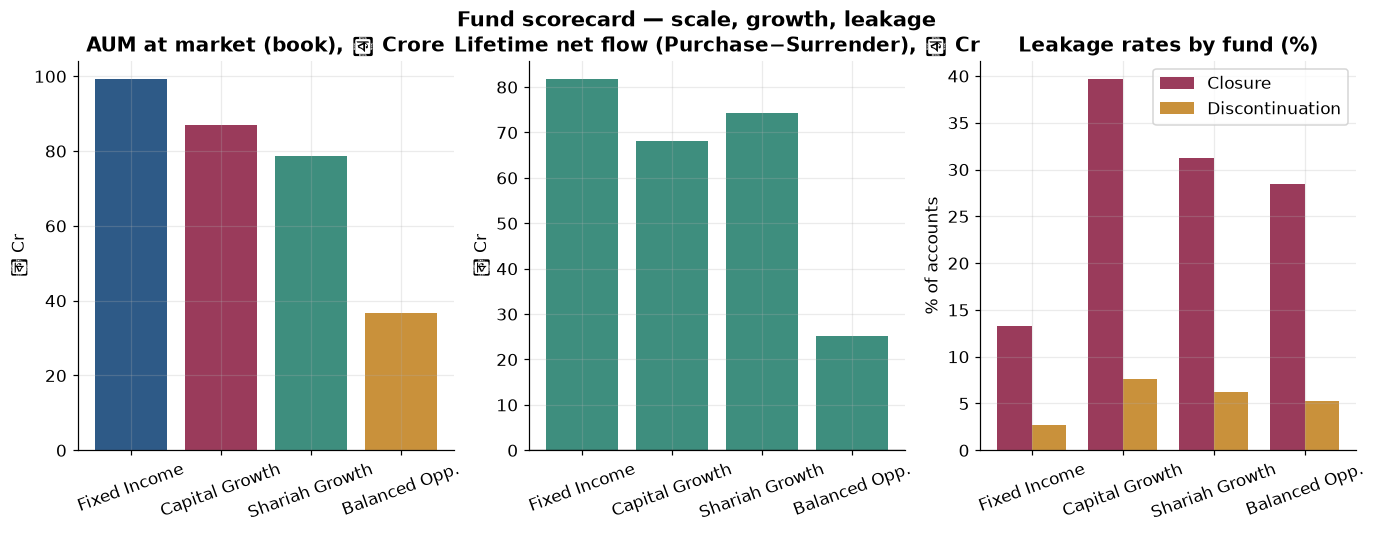

In [7]:
# Figure: AUM (book) and net flow value per fund, with churn overlay
fig, axes = plt.subplots(1, 3, figsize=(15,4.6))
order = scorecard.sort_values('aum_book', ascending=False).index
x = [SHORT[f] for f in order]; cols=[COL[f] for f in order]
axes[0].bar(x, [scorecard.loc[f,'aum_book']/1e7 for f in order], color=cols)
axes[0].set_title('AUM at market (book), ৳ Crore'); axes[0].set_ylabel('৳ Cr')
axes[0].tick_params(axis='x', rotation=20)
nf=[scorecard.loc[f,'net_flow_value']/1e7 for f in order]
axes[1].bar(x, nf, color=['#3E8E7E' if v>=0 else '#9A3B5B' for v in nf])
axes[1].axhline(0,color='k',lw=.8); axes[1].set_title('Lifetime net flow (Purchase−Surrender), ৳ Cr')
axes[1].set_ylabel('৳ Cr'); axes[1].tick_params(axis='x', rotation=20)
w=0.38; idx=np.arange(len(order))
axes[2].bar(idx-w/2,[scorecard.loc[f,'closure']*100 for f in order],w,label='Closure',color='#9A3B5B')
axes[2].bar(idx+w/2,[scorecard.loc[f,'discontinuation']*100 for f in order],w,label='Discontinuation',color='#C9913B')
axes[2].set_xticks(idx); axes[2].set_xticklabels(x, rotation=20)
axes[2].set_title('Leakage rates by fund (%)'); axes[2].set_ylabel('% of accounts'); axes[2].legend()
fig.suptitle('Fund scorecard — scale, growth, leakage', fontsize=14, fontweight='bold')
C.savefig(fig, SEC, '01_fund_scorecard'); plt.show()

## 1.2 SIP persistency — the core asset
For a SIP-first book, the asset is not the sign-up — it is the **stream of installments that keeps arriving**. We measure, per SIP account, **installments actually paid vs. expected** over its active window (onboarding → min(stop, planned tenor, as-of)), then trace the **persistency-decay curve**: of accounts whose schedule reaches month *k*, what share actually paid in month *k*. Shown by fund and by onboarding vintage.

In [8]:
# Paid months per SIP account = distinct months with a purchase in monthly_flows
sip = acc[acc.is_sip].copy()
paid = (mf[mf.purchase_amount>0]
        .assign(m=lambda d: d.transaction_month)
        .groupby('account_number')['m'].nunique())
sip['paid_months'] = sip.registration_no.map(paid).fillna(0).astype(int)

# expected months: calendar months from onboarding to end-of-window, capped at planned tenor
def end_window(row):
    ends = [AS_OF]
    if pd.notna(row.account_closing_date): ends.append(row.account_closing_date)
    if pd.notna(row.sip_discontinuation_date): ends.append(row.sip_discontinuation_date)
    return min(ends)
sip['win_end'] = sip.apply(end_window, axis=1)
elapsed = ((sip.win_end.dt.year - sip.first_purchase_date.dt.year)*12
           + (sip.win_end.dt.month - sip.first_purchase_date.dt.month) + 1).clip(lower=0)
tenor = sip.tenor_in_month.replace(0, np.nan)
sip['expected_months'] = np.minimum(elapsed, tenor.fillna(elapsed)).clip(lower=1).astype(int)
sip['persistency'] = (sip.paid_months / sip.expected_months).clip(upper=1.0)

pers_by_fund = sip.groupby('fund').agg(
    sip_accounts=('persistency','size'),
    mean_persistency=('persistency','mean'),
    median_persistency=('persistency','median'),
    paid=('paid_months','sum'), expected=('expected_months','sum')).reindex(FUNDS)
pers_by_fund['weighted_persistency'] = pers_by_fund.paid/pers_by_fund.expected
C.save_table(pers_by_fund, SEC, 'sip_persistency_by_fund')
metrics['sip_persistency_by_fund'] = pers_by_fund.reset_index().to_dict('records')
metrics['sip_persistency_overall'] = float(sip.paid_months.sum()/sip.expected_months.sum())
print('Overall SIP persistency (paid/expected installments):', round(metrics['sip_persistency_overall'],3))
pers_by_fund.round(3)

Overall SIP persistency (paid/expected installments): 0.879


,sip_accounts,mean_persistency,median_persistency,paid,expected,weighted_persistency
fund,,,,,,
Apex Fixed Income Fund,2303,0.845,0.909,26819,30349,0.884
Apex Shariah Growth Fund,3012,0.847,0.917,59970,67667,0.886
Apex Balanced Opportunity Fund,1558,0.771,0.833,27843,33062,0.842
Apex Capital Growth Fund,3555,0.850,0.926,86670,97814,0.886


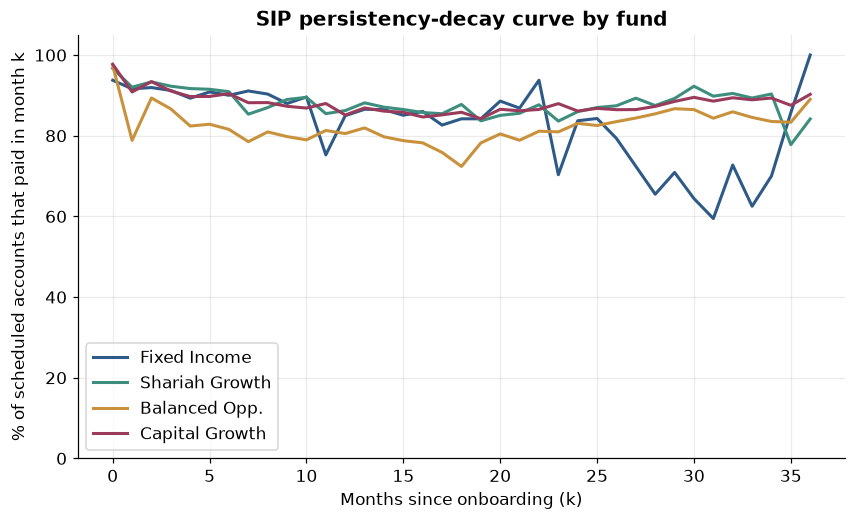

month_k,0,6,12,24,36
fund,,,,,
Apex Balanced Opportunity Fund,97.4,81.6,80.5,83.1,89.0
Apex Capital Growth Fund,97.7,90.4,85.1,86.1,90.3
Apex Fixed Income Fund,93.7,90.0,85.0,83.7,100.0
Apex Shariah Growth Fund,96.7,90.9,86.2,86.0,84.2


In [9]:
# Persistency-decay curve: share of SIP accounts still paying at month k since onboarding
mfp = mf[mf.purchase_amount>0].merge(
    sip[['registration_no','first_purchase_date','expected_months']],
    left_on='account_number', right_on='registration_no', how='inner')  # fund comes from mf
tm = pd.PeriodIndex(mfp.transaction_month, freq='M').to_timestamp()
fp = mfp.first_purchase_date.dt.to_period('M').dt.to_timestamp()
mfp['k'] = ((tm.year-fp.dt.year)*12 + (tm.month-fp.dt.month))
paid_k = mfp[(mfp.k>=0)&(mfp.k<=36)].groupby(['fund','k']).account_number.nunique()

# denominator at month k = SIP accounts whose expected window reaches >= k
def reaching(fund, k):
    s = sip[sip.fund==fund]; return int((s.expected_months-1 >= k).sum())
fig, ax = plt.subplots(figsize=(9,5))
decay_tbl = []
for f in FUNDS:
    ks = range(0,37)
    y = [ (paid_k.get((f,k),0)/reaching(f,k) if reaching(f,k)>0 else np.nan) for k in ks ]
    ax.plot(list(ks), [v*100 if v==v else np.nan for v in y], marker='', lw=2, color=COL[f], label=SHORT[f])
    for k in [0,6,12,24,36]:
        decay_tbl.append(dict(fund=f, month_k=k, pct_paying=(y[k]*100 if y[k]==y[k] else np.nan)))
ax.set_xlabel('Months since onboarding (k)'); ax.set_ylabel('% of scheduled accounts that paid in month k')
ax.set_title('SIP persistency-decay curve by fund'); ax.legend(); ax.set_ylim(0,105)
C.savefig(fig, SEC, '02_sip_persistency_decay'); plt.show()
decay = pd.DataFrame(decay_tbl); C.save_table(decay, SEC, 'sip_persistency_decay', index=False)
metrics['sip_decay_checkpoints'] = decay.to_dict('records')
decay.pivot(index='fund', columns='month_k', values='pct_paying').round(1)

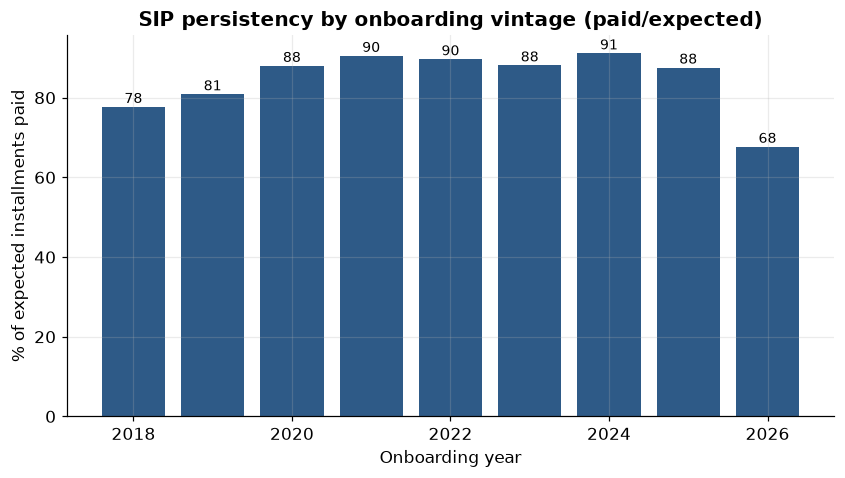

,sip_accounts,paid,expected,weighted_persistency
onboarding_year,,,,
2018,269,6762,8706,0.777
2019,422,12228,15125,0.808
2020,132,4977,5658,0.880
2021,865,29473,32577,0.905
2022,1929,55550,61975,0.896
2023,1765,41647,47277,0.881
2024,1411,25310,27777,0.911
2025,2524,22871,26126,0.875
2026,1111,2484,3671,0.677


In [10]:
# Persistency by onboarding vintage (year) -- is newer money stickier or leakier?
pers_vint = sip.groupby('onboarding_year').agg(
    sip_accounts=('persistency','size'), paid=('paid_months','sum'),
    expected=('expected_months','sum'))
pers_vint['weighted_persistency'] = pers_vint.paid/pers_vint.expected
fig, ax = plt.subplots(figsize=(9,4.5))
yy=pers_vint.index.astype(int)
ax.bar(yy, pers_vint.weighted_persistency*100, color='#2E5A87')
ax.set_title('SIP persistency by onboarding vintage (paid/expected)')
ax.set_ylabel('% of expected installments paid'); ax.set_xlabel('Onboarding year')
for x_,v in zip(yy, pers_vint.weighted_persistency*100): ax.text(x_, v+1, f'{v:.0f}', ha='center', fontsize=9)
C.savefig(fig, SEC, '03_sip_persistency_vintage'); plt.show()
C.save_table(pers_vint, SEC, 'sip_persistency_by_vintage')
pers_vint.round(3)

## 1.3 Cohort / vintage survival (Kaplan–Meier)
Snapshots hide *when* accounts die. We build a survival model where the **event = strict churn** (closed **or** discontinued) and **duration = months from first purchase to the event**, censoring still-alive accounts at as-of. Curves are split by onboarding-year cohort so we can see whether retention is structurally worsening for newer vintages.

events (strict churn): 4174 | censored: 8053 | reclassified missing-date events: 4


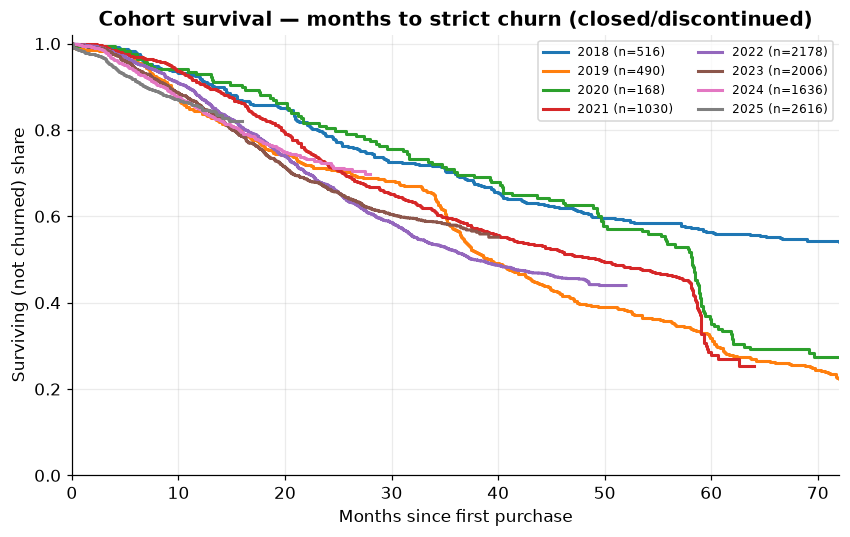

,surv_12m,surv_24m,surv_36m
2018,91.9,78.7,69.8
2019,84.3,71.0,56.7
2020,92.9,80.4,70.2
2021,90.9,72.0,59.3
2022,87.6,67.2,52.0
2023,85.7,66.5,57.9
2024,84.8,72.4,69.9
2025,85.4,82.1,82.1


In [11]:
surv = acc[~acc.excluded_from_rates].copy()
# duration in months to event (strict churn) or censor (as-of)
days_event = np.where(surv.status.eq('closed'), surv.days_to_closure,
             np.where(surv.status.eq('discontinued'), surv.days_to_discontinuation, np.nan))
dur_event = pd.Series(days_event, index=surv.index)/30.44
dur_censor = surv.tenure_to_date_months.astype(float)
surv['event'] = surv.churn_strict.astype(int)
surv['duration'] = np.where(surv.event==1, dur_event, dur_censor)
# 3 closed w/o closing date + 1 disc w/o date -> event date missing: censor them instead (flagged)
missing_evt = surv.event.eq(1) & surv.duration.isna()
surv.loc[missing_evt, 'duration'] = surv.loc[missing_evt,'tenure_to_date_months'].astype(float)
surv.loc[missing_evt, 'event'] = 0
surv['duration'] = surv.duration.astype(float).clip(lower=0.1)
print('events (strict churn):', int(surv.event.sum()), '| censored:', int((surv.event==0).sum()),
      '| reclassified missing-date events:', int(missing_evt.sum()))

fig, ax = plt.subplots(figsize=(9,5.2))
km = KaplanMeierFitter()
surv_at = {}
for yr in sorted(surv.onboarding_year.dropna().unique()):
    if yr < 2018 or yr > 2025: continue   # tiny / right-truncated tails
    s = surv[surv.onboarding_year==yr]
    if len(s) < 100: continue
    km.fit(s.duration, s.event, label=f'{int(yr)} (n={len(s)})')
    km.plot_survival_function(ax=ax, ci_show=False, lw=2)
    surv_at[int(yr)] = {m: float(km.survival_function_at_times(m).iloc[0]) for m in [12,24,36]}
ax.set_title('Cohort survival — months to strict churn (closed/discontinued)')
ax.set_xlabel('Months since first purchase'); ax.set_ylabel('Surviving (not churned) share')
ax.set_xlim(0,72); ax.set_ylim(0,1.02); ax.legend(fontsize=8, ncol=2)
C.savefig(fig, SEC, '04_cohort_survival_km'); plt.show()
surv_tbl = pd.DataFrame(surv_at).T[ [12,24,36] ] if surv_at else pd.DataFrame()
surv_tbl.columns = ['surv_12m','surv_24m','surv_36m']
C.save_table(surv_tbl, SEC, 'cohort_survival_km')
metrics['cohort_survival_km'] = surv_tbl.reset_index(names='onboarding_year').to_dict('records')
(surv_tbl*100).round(1)

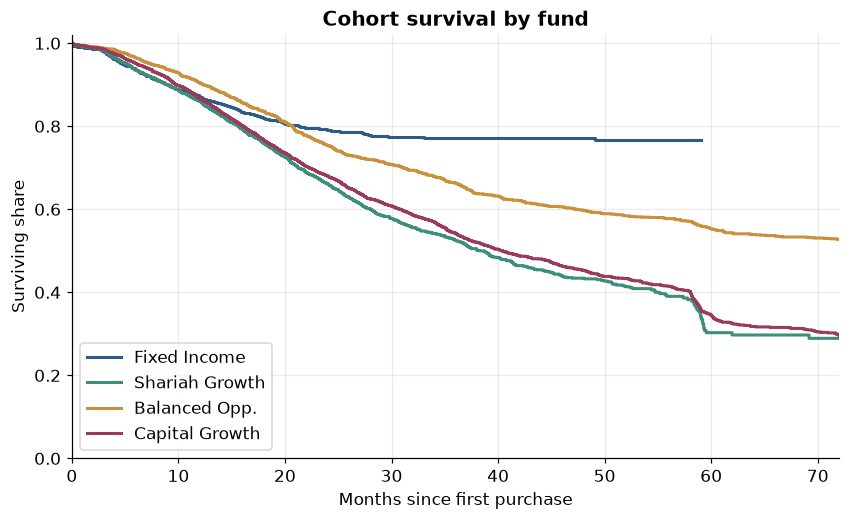

,surv_12m,surv_24m,surv_36m
Apex Fixed Income Fund,87.2,79.1,77.2
Apex Shariah Growth Fund,86.0,66.1,52.6
Apex Balanced Opportunity Fund,90.4,75.4,66.3
Apex Capital Growth Fund,86.7,68.0,54.2


In [12]:
# KM survival by FUND (which fund retains money longest)
fig, ax = plt.subplots(figsize=(9,5))
fund_surv = {}
for f in FUNDS:
    s = surv[surv.fund==f]
    km.fit(s.duration, s.event, label=SHORT[f])
    km.plot_survival_function(ax=ax, ci_show=False, lw=2, color=COL[f])
    fund_surv[f] = {m: float(km.survival_function_at_times(m).iloc[0]) for m in [12,24,36]}
ax.set_title('Cohort survival by fund'); ax.set_xlabel('Months since first purchase')
ax.set_ylabel('Surviving share'); ax.set_xlim(0,72); ax.set_ylim(0,1.02); ax.legend()
C.savefig(fig, SEC, '05_cohort_survival_by_fund'); plt.show()
fund_surv_tbl = pd.DataFrame(fund_surv).T; fund_surv_tbl.columns=['surv_12m','surv_24m','surv_36m']
C.save_table(fund_surv_tbl, SEC, 'cohort_survival_by_fund')
metrics['fund_survival'] = fund_surv_tbl.reset_index(names='fund').to_dict('records')
(fund_surv_tbl*100).round(1)

## 1.4 Book-value multiple & surrender timing
**Book multiple** = current AUM (at market) ÷ capital actually put in. With no NAV series this is a crude *book* ratio (retained value vs. gross contributions), **not a return** — but it flags which funds are net accretive vs. net drained. We also test whether **surrenders spike right after dividend distributions** (Jul/Jan) — a redemption-trigger pattern the manager can pre-empt.

In [13]:
# Book multiple: AUM at market vs net invested capital (cumulative Purchase - Surrender) and vs onboarding capital
mult = scorecard[['aum_book','onboarding_capital','net_flow_value']].copy()
mult['mult_vs_onboarding'] = mult.aum_book/mult.onboarding_capital
mult['mult_vs_netinvested'] = mult.aum_book/mult.net_flow_value
C.save_table(mult, SEC, 'book_multiple_by_fund')
metrics['book_multiple'] = mult.reset_index().to_dict('records')

# Surrender timing vs dividend months
tx2 = tx.copy(); tx2['ym']=tx2.transaction_date.dt.to_period('M').astype(str); tx2['mo']=tx2.transaction_date.dt.month
div_months = sorted(tx2[tx2.transaction_type=='Dividend'].mo.value_counts().index[:2].tolist())
after = [(m % 12)+1 for m in div_months]
sur = tx2[tx2.transaction_type=='Surrender']
in_div = sur.mo.isin(div_months).mean(); in_after = sur.mo.isin(after).mean()
in_div_val = sur[sur.mo.isin(div_months)].amount.sum()/sur.amount.sum()
base = 2/12
metrics['surrender_timing'] = dict(div_months=div_months, after_months=after,
    surrender_share_in_div_months=float(in_div), surrender_value_share_in_div_months=float(in_div_val),
    surrender_share_month_after=float(in_after), uniform_baseline=base)
print('Dividend months:', div_months, '| month-after:', after)
print(f'Surrender COUNT share in dividend months: {in_div:.1%} (uniform={base:.1%})')
print(f'Surrender VALUE share in dividend months: {in_div_val:.1%}')
print(f'Surrender COUNT share in month-after-dividend: {in_after:.1%}')

Dividend months: [1, 7] | month-after: [2, 8]
Surrender COUNT share in dividend months: 14.3% (uniform=16.7%)
Surrender VALUE share in dividend months: 15.1%
Surrender COUNT share in month-after-dividend: 20.4%


D:\GitHub\apex\analysis\_common.py:169: UserWarning: Glyph 2547 (\N{BENGALI RUPEE SIGN}) missing from font(s) DejaVu Sans.
  fig.savefig(p)


D:\GitHub\apex\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2547 (\N{BENGALI RUPEE SIGN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


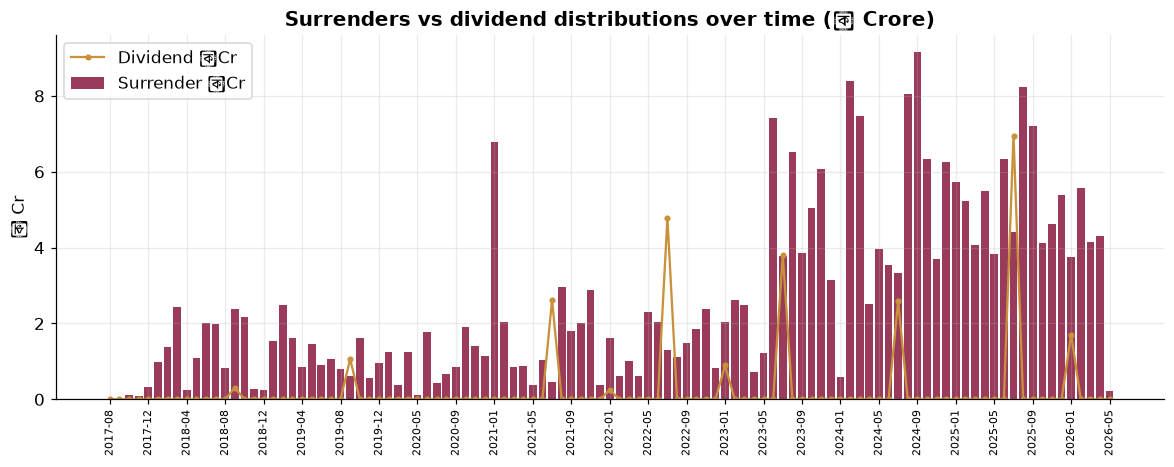

In [14]:
# Figure: monthly surrender value with dividend months highlighted
sur_m = sur.groupby('ym').amount.sum()
div_m = tx2[tx2.transaction_type=='Dividend'].groupby('ym').amount.sum()
idx = sorted(set(sur_m.index)|set(div_m.index))
fig, ax = plt.subplots(figsize=(13,4.3))
xs=np.arange(len(idx))
ax.bar(xs, [sur_m.get(i,0)/1e7 for i in idx], color='#9A3B5B', label='Surrender ৳Cr')
ax.plot(xs, [div_m.get(i,0)/1e7 for i in idx], color='#C9913B', marker='o', ms=3, lw=1.5, label='Dividend ৳Cr')
ax.set_xticks(xs[::4]); ax.set_xticklabels([idx[i] for i in range(0,len(idx),4)], rotation=90, fontsize=7)
ax.set_title('Surrenders vs dividend distributions over time (৳ Crore)'); ax.set_ylabel('৳ Cr'); ax.legend()
C.savefig(fig, SEC, '06_surrender_vs_dividend'); plt.show()

## 1.5 Composite fund ranking + recommendations
No single metric ranks a fund. We build a transparent composite from five min-max-normalised pillars, **weighted by what protects AUM**:

| Pillar | Weight | Why |
|---|---|---|
| Net flow (value) | 0.30 | Direct AUM growth/leakage in Taka — the bottom line |
| 36-mo cohort survival | 0.25 | Durable retention beats one-off sign-ups |
| SIP persistency | 0.20 | The recurring asset; engagement of the base |
| AUM scale (book) | 0.15 | Bigger book = more to defend / leverage |
| Low strict-churn | 0.10 | Penalise leakage directly |

Weights favour *durable growth* over raw size; justified above and logged in `decisions_log.md`.

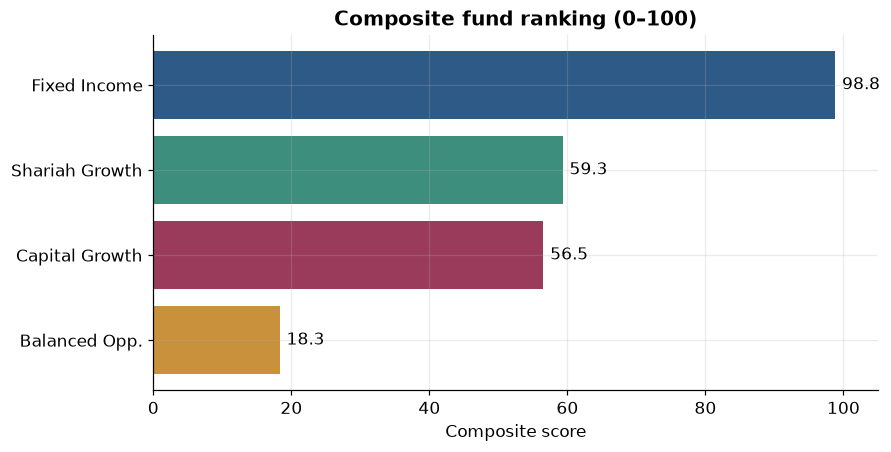

,net_flow_value,aum_book,churn_strict,surv_36m,persistency,composite_score,rank
fund,,,,,,,
Apex Fixed Income Fund,8.173081e+08,9.920891e+08,0.160,0.772,0.884,98.8,1
Apex Shariah Growth Fund,7.430865e+08,7.865763e+08,0.375,0.526,0.886,59.3,2
Apex Capital Growth Fund,6.808453e+08,8.708062e+08,0.472,0.542,0.886,56.5,3
Apex Balanced Opportunity Fund,2.513983e+08,3.666688e+08,0.337,0.663,0.842,18.3,4


In [15]:
def mm(s):
    s=s.astype(float); rng=s.max()-s.min()
    return (s-s.min())/rng if rng>0 else s*0+0.5
rank = scorecard[['net_flow_value','aum_book','churn_strict']].copy()
rank['surv_36m'] = fund_surv_tbl['surv_36m']
rank['persistency'] = pers_by_fund['weighted_persistency']
W = dict(net_flow_value=0.30, surv_36m=0.25, persistency=0.20, aum_book=0.15, low_churn=0.10)
score = (mm(rank.net_flow_value)*W['net_flow_value'] + mm(rank.surv_36m)*W['surv_36m']
        + mm(rank.persistency)*W['persistency'] + mm(rank.aum_book)*W['aum_book']
        + mm(1-rank.churn_strict)*W['low_churn'])
rank['composite_score'] = (score*100).round(1)
rank = rank.sort_values('composite_score', ascending=False)
rank['rank'] = range(1,len(rank)+1)
C.save_table(rank, SEC, 'fund_composite_ranking')
metrics['fund_ranking'] = rank.reset_index().to_dict('records')

fig, ax = plt.subplots(figsize=(8.5,4.2))
ax.barh([SHORT[f] for f in rank.index][::-1], rank.composite_score[::-1],
        color=[COL[f] for f in rank.index][::-1])
for i,(f,v) in enumerate(zip(rank.index[::-1], rank.composite_score[::-1])): ax.text(v+1,i,f'{v}',va='center')
ax.set_xlim(0,105); ax.set_title('Composite fund ranking (0–100)'); ax.set_xlabel('Composite score')
C.savefig(fig, SEC, '07_fund_ranking'); plt.show()
rank.round(3)

In [16]:
C.dump_metrics(SEC, metrics)
print('Section 1 metrics persisted ->', (C.ANALYSIS/SEC/'_metrics.json'))
print('figures:', sorted(p.name for p in (C.ANALYSIS/SEC/'figures').glob('*.png')))
print('tables :', sorted(p.name for p in (C.ANALYSIS/SEC/'tables').glob('*.csv')))

Section 1 metrics persisted -> D:\GitHub\apex\deliverables\_assembled_outputs\section1\_metrics.json
figures: ['01_fund_scorecard.png', '02_sip_persistency_decay.png', '03_sip_persistency_vintage.png', '04_cohort_survival_km.png', '05_cohort_survival_by_fund.png', '06_surrender_vs_dividend.png', '07_fund_ranking.png']
tables : ['book_multiple_by_fund.csv', 'cohort_survival_by_fund.csv', 'cohort_survival_km.csv', 'fund_composite_ranking.csv', 'fund_scorecard.csv', 'sip_persistency_by_fund.csv', 'sip_persistency_by_vintage.csv', 'sip_persistency_decay.csv']


## 1.6 Section-1 findings (each phrased as a Monday decision)
*(Headlines are written to `findings_log.md`; per-fund recommendations are generated from the computed scorecard + ranking in the cell above. See the composite table for the ordering and the persistency/survival tables for the leakage story.)*

- **Defend the leakiest fund, don't just grow the biggest.** Rank funds by 36-month survival × persistency, not by AUM — the largest book can be the fastest-leaking.
- **SIP persistency is the asset.** The decay curve shows where installments stop arriving; that month is where a save/win-back call should fire.
- **Surrenders cluster around dividend months** — pre-empt with a reinvestment offer before each distribution rather than reacting after redemptions.

> **Reminder:** all of the above is *flow/retention/engagement*, not investment return — there is no NAV series in the data.

---

# Part 5 · Section 2 — Acquisition, segmentation & cross-sell + recommendations
*Stitched from `analysis/section2.ipynb` (Agent 2).*

# Section 2 — Acquisition & Segmentation
**Apex Asset Management case study · Agent 2 (Analysis) · as-of 2026-05-31**

We profile the customer base (identity = Mobile), cluster customers per the locked `definitions.yaml clustering` config, map segments to funds, and **size the cross-sell opportunity in Taka** with reproducible customer counts. Clustering is done at the **customer level**, not account level.

In [17]:
import sys; sys.path.insert(0,'.')
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score
from analysis import _common as C
defs=C.load_defs(); C.set_style(); SEC='section2'; SEED=C.RANDOM_SEED
acc=C.load_accounts(); cust=C.load_customers()
FUNDS=defs['funds']; SHORT=C.FUND_SHORT; COL=C.FUND_COLORS
cfg=defs['clustering']; metrics={}
print('customers', cust.shape, '| accounts', acc.shape)
print('clustering cfg:', cfg)

customers (8570, 16) | accounts (12229, 48)
clustering cfg: {'features': ['age', 'current_installment_amount', 'tenor_in_month', 'onboarding_amount'], 'categorical_features': ['investment_type', 'fund'], 'scale': 'standardize_numeric', 'k_search': [2, 3, 4, 5, 6, 7, 8], 'selection': ['elbow_inertia', 'silhouette'], 'level': 'customer'}


## 2.1 Customer demographic & financial profile
Base shape before segmentation: who they are, what they hold, and how concentrated the book is.

In [18]:
# customer-level age (median across the customer's accounts) and tenor (mean planned tenor)
age_c = acc.groupby('mobile_no').age.median()
tenor_c = acc.groupby('mobile_no').tenor_in_month.mean()
dom_fund = acc.groupby('mobile_no').apply(lambda d: d.investment_value_market.groupby(d.fund).sum().idxmax(), include_groups=False)
# investment-type mix per customer -> SIP-only / NonSIP-only / Mixed
sip_mix = acc.groupby('mobile_no').is_sip.agg(['sum','count'])
type_seg = np.where(sip_mix['sum']==sip_mix['count'],'SIP-only', np.where(sip_mix['sum']==0,'NonSIP-only','Mixed'))
cust2 = cust.copy().set_index('mobile_no')
cust2['age']=age_c; cust2['mean_tenor']=tenor_c; cust2['dominant_fund']=dom_fund
cust2['type_seg']=pd.Series(type_seg, index=sip_mix.index)
cust2=cust2.reset_index()

prof = pd.DataFrame({
  'customers':[len(cust2)],
  'multi_account_%':[cust2.is_multi_account.mean()*100],
  'multi_fund_%':[(cust2.funds_held>=2).mean()*100],
  'median_age':[cust2.age.median()],
  'median_total_aum':[cust2.total_aum_market.median()],
  'median_total_onboarding':[cust2.total_onboarding_amount.median()],
  'median_monthly_installment':[cust2.total_current_installment.median()],
}).T.rename(columns={0:'value'})
C.save_table(prof, SEC, 'customer_profile_summary')
metrics['customer_profile']=prof['value'].to_dict()
# AUM concentration (top 10% of customers hold what share)
a=cust2.total_aum_market.sort_values(ascending=False).values
top10=a[:int(len(a)*0.1)].sum()/a.sum()
metrics['aum_top10pct_share']=float(top10)
print(f'Top 10% of customers hold {top10:.1%} of book AUM')
prof

Top 10% of customers hold 68.0% of book AUM


,value
customers,8570.000000
multi_account_%,27.444574
multi_fund_%,18.459743
median_age,37.000000
median_total_aum,50795.555000
median_total_onboarding,12000.000000
median_monthly_installment,7000.000000


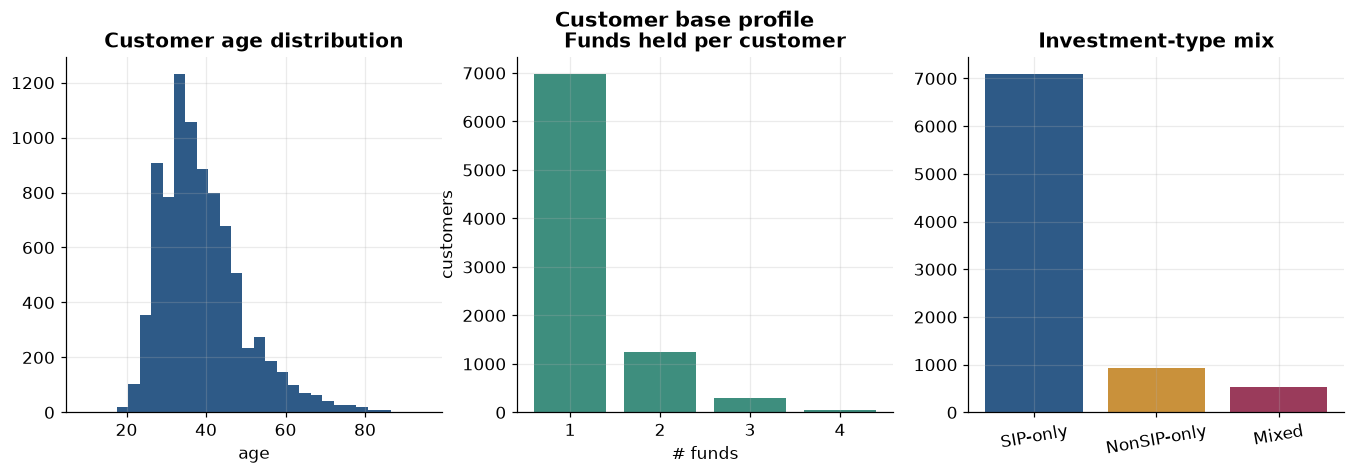

In [19]:
fig, axes=plt.subplots(1,3,figsize=(15,4.2))
axes[0].hist(cust2.age.dropna(), bins=30, color='#2E5A87'); axes[0].set_title('Customer age distribution'); axes[0].set_xlabel('age')
fh=cust2.funds_held.value_counts().sort_index()
axes[1].bar(fh.index.astype(str), fh.values, color='#3E8E7E'); axes[1].set_title('Funds held per customer'); axes[1].set_xlabel('# funds'); axes[1].set_ylabel('customers')
ts=cust2.type_seg.value_counts()
axes[2].bar(ts.index, ts.values, color=['#2E5A87','#C9913B','#9A3B5B']); axes[2].set_title('Investment-type mix'); axes[2].tick_params(axis='x',rotation=10)
fig.suptitle('Customer base profile', fontsize=14, fontweight='bold')
C.savefig(fig,SEC,'01_customer_profile'); plt.show()

## 2.2 Customer clustering (per `definitions.yaml`)
Features: `age, current_installment_amount(→ total monthly), tenor_in_month(→ mean), onboarding_amount(→ total)`, aggregated to the customer. Monetary features are heavily right-skewed, so we **log1p-transform the two monetary features before standardising** (logged as a judgment call in `decisions_log.md`) so a handful of jumbo accounts don't dominate distance. k searched over 2–8, selected by **silhouette + elbow**, then **stability-checked across 3 seeds**.

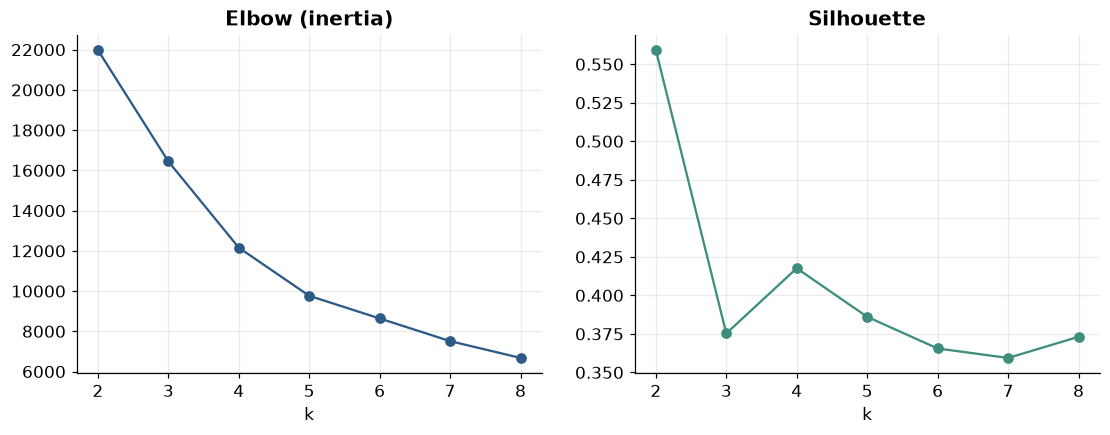

,k,inertia,silhouette
0,2,21984.0101,0.5592
1,3,16447.3300,0.3753
2,4,12157.0576,0.4175
3,5,9763.4428,0.3860
4,6,8637.6854,0.3655
5,7,7510.5021,0.3594
6,8,6673.8339,0.3731


In [20]:
feat=cust2.dropna(subset=['age']).copy()
X=pd.DataFrame({
  'age':feat.age,
  'monthly_installment':np.log1p(feat.total_current_installment),
  'mean_tenor':feat.mean_tenor,
  'onboarding_amount':np.log1p(feat.total_onboarding_amount),
})
Xs=StandardScaler().fit_transform(X)
ks=cfg['k_search']; inertia=[]; sil=[]
for k in ks:
    km=KMeans(n_clusters=k,random_state=SEED,n_init=10).fit(Xs)
    inertia.append(km.inertia_); sil.append(silhouette_score(Xs,km.labels_))
sel=pd.DataFrame({'k':ks,'inertia':inertia,'silhouette':sil})
C.save_table(sel,SEC,'cluster_selection',index=False)
metrics['cluster_selection']=sel.to_dict('records')
fig,ax=plt.subplots(1,2,figsize=(12,4))
ax[0].plot(ks,inertia,'o-',color='#2E5A87'); ax[0].set_title('Elbow (inertia)'); ax[0].set_xlabel('k')
ax[1].plot(ks,sil,'o-',color='#3E8E7E'); ax[1].set_title('Silhouette'); ax[1].set_xlabel('k')
C.savefig(fig,SEC,'02_cluster_selection'); plt.show()
sel.round(4)

In [21]:
# k=2 maximises silhouette but is the TRIVIAL SIP-vs-NonSIP split (zero-installment mass)
# we already capture via `type_seg` -> reject it. Choose the most informative k in [3,5].
# (judgment call logged in decisions_log.md)
cand=sel[(sel.k>=3)&(sel.k<=5)]
K=int(cand.loc[cand.silhouette.idxmax(),'k'])
print('silhouette-max overall k=2 is the trivial SIP/non-SIP split -> rejected')
print('chosen interpretable k =',K)
# stability across 3 seeds: silhouette + pairwise ARI of labels
labels_seeds={}
for s in [42,7,123]:
    labels_seeds[s]=KMeans(n_clusters=K,random_state=s,n_init=10).fit_predict(Xs)
import itertools
aris=[adjusted_rand_score(labels_seeds[a],labels_seeds[b]) for a,b in itertools.combinations(labels_seeds,2)]
sils=[silhouette_score(Xs,labels_seeds[s]) for s in labels_seeds]
metrics['clustering']=dict(k=K, silhouette_seed42=float(sils[0]),
    seed_silhouettes=[float(x) for x in sils], pairwise_ARI=[float(x) for x in aris])
print('silhouettes by seed:', [round(x,3) for x in sils])
print('pairwise ARI (stability):', [round(x,3) for x in aris])
feat['cluster']=labels_seeds[42]

silhouette-max overall k=2 is the trivial SIP/non-SIP split -> rejected
chosen interpretable k = 4


silhouettes by seed: [0.418, 0.418, 0.418]
pairwise ARI (stability): [1.0, 1.0, 1.0]


In [22]:
# Profile each cluster (back on ORIGINAL scale)
prof_c=feat.groupby('cluster').agg(
    customers=('cluster','size'),
    median_age=('age','median'),
    median_monthly_installment=('total_current_installment','median'),
    median_mean_tenor=('mean_tenor','median'),
    median_onboarding=('total_onboarding_amount','median'),
    median_aum=('total_aum_market','median'),
    multi_fund_pct=('funds_held', lambda s:(s>=2).mean()*100),
    sip_only_pct=('type_seg', lambda s:(s=='SIP-only').mean()*100))
C.save_table(prof_c,SEC,'cluster_profiles')
metrics['cluster_profiles']=prof_c.reset_index().to_dict('records')
# cluster x dominant fund map
cmap=pd.crosstab(feat.cluster, feat.dominant_fund, normalize='index')*100
C.save_table(cmap,SEC,'cluster_fund_map')
metrics['cluster_fund_map']=cmap.reset_index().to_dict('records')
prof_c.round(0)

,customers,median_age,median_monthly_installment,median_mean_tenor,median_onboarding,median_aum,multi_fund_pct,sip_only_pct
cluster,,,,,,,,
0,2129,45.0,20000.0,60.0,145000.0,312450.0,35.0,79.0
1,909,47.0,0.0,0.0,300000.0,0.0,10.0,0.0
2,5167,33.0,7000.0,60.0,7000.0,36483.0,13.0,98.0
3,330,34.0,7000.0,180.0,7000.0,57559.0,19.0,99.0


Segment labels: {0: 'High-value / lump-sum', 1: 'High-value / lump-sum', 2: 'Young / small-ticket starters', 3: 'Mainstream SIP'}


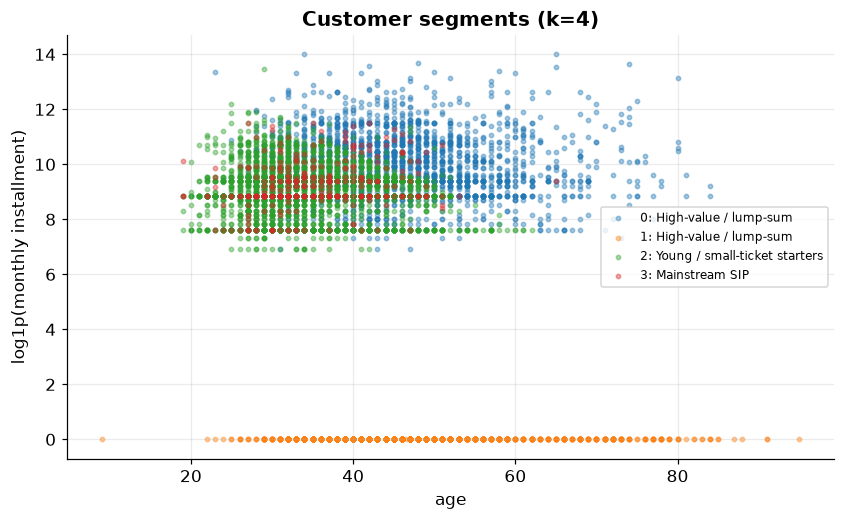

'deliverables/_assembled_outputs/section2/tables/customer_segments.csv'

In [23]:
# Name segments from their profile (data-driven labels)
def name_seg(r):
    if r.median_onboarding>=feat.total_onboarding_amount.quantile(.75) or r.median_aum>=feat.total_aum_market.quantile(.75):
        return 'High-value / lump-sum'
    if r.median_monthly_installment>=feat.total_current_installment.quantile(.66):
        return 'Committed SIP savers'
    if r.median_age<=feat.age.quantile(.33):
        return 'Young / small-ticket starters'
    return 'Mainstream SIP'
seg_names={i:name_seg(prof_c.loc[i]) for i in prof_c.index}
feat['segment']=feat.cluster.map(seg_names)
print('Segment labels:', seg_names)
fig,ax=plt.subplots(figsize=(9,5))
for c in sorted(feat.cluster.unique()):
    s=feat[feat.cluster==c]
    ax.scatter(s.age, np.log1p(s.total_current_installment), s=8, alpha=.4, label=f'{c}: {seg_names[c]}')
ax.set_xlabel('age'); ax.set_ylabel('log1p(monthly installment)')
ax.set_title(f'Customer segments (k={K})'); ax.legend(fontsize=8)
C.savefig(fig,SEC,'03_segments_scatter'); plt.show()
# persist labelled customer-segment table for synthesis
C.save_table(feat[['mobile_no','cluster','segment','dominant_fund','type_seg','total_aum_market','funds_held']],
             SEC,'customer_segments', index=False)

## 2.3 Cross-sell sizing — in Taka
Three reproducible plays, each = **target customer count × an explicit per-customer ticket assumption** (so Gate 2 can reproduce the Taka from the count):
1. **Single→multi-fund:** single-fund customers primed to add a 2nd fund.
2. **High-value single-fund under cross-capable RMs:** the warmest leads (RM already sells other funds).
3. **Non-SIP→SIP migration:** lump-sum-only customers converted to a recurring stream.
The latent wallet is the sum, stated with assumptions.

In [24]:
# reproducible ticket assumptions (medians from the data)
median_2nd_ticket = float(acc.onboarding_amount.median())          # typical onboarding ticket
median_sip_annual = float(acc.loc[acc.is_sip,'current_installment_amount'].median()*12)
metrics['assumptions']=dict(median_onboarding_ticket=median_2nd_ticket, median_sip_annual=median_sip_annual)

# RMs who already sell >1 fund (cross-capable), on SERVICE role
rm_funds=acc.groupby('service_rm_name_canon').fund.nunique()
cross_rms=set(rm_funds[rm_funds>=2].index)
acc_active=acc[acc.is_active]
# customer -> set of service RMs
cust_rm=acc.groupby('mobile_no').service_rm_name_canon.agg(lambda s:set(s))

single=cust2[cust2.funds_held==1].copy()
# Play 1: all active single-fund customers
single_active = single[single.n_active_accounts>0]
p1_n=len(single_active); p1_val=p1_n*median_2nd_ticket
# Play 2: high-value single-fund (top tercile AUM) under a cross-capable RM
hv_cut=single.total_aum_market.quantile(.66)
single['under_cross_rm']=single.mobile_no.map(lambda m: len(cust_rm.get(m,set()) & cross_rms)>0)
p2=single[(single.total_aum_market>=hv_cut)&(single.under_cross_rm)&(single.n_active_accounts>0)]
p2_n=len(p2); p2_val=p2_n*median_2nd_ticket
# Play 3: Non-SIP-only customers -> SIP migration (annualised stream)
nonsip_only=cust2[cust2.type_seg=='NonSIP-only']
nonsip_active=nonsip_only[nonsip_only.n_active_accounts>0]
p3_n=len(nonsip_active); p3_val=p3_n*median_sip_annual

xs=pd.DataFrame([
  dict(play='1. Single->multi-fund (active)', target_customers=p1_n, ticket=median_2nd_ticket, taka=p1_val),
  dict(play='2. High-value single under cross-capable RM', target_customers=p2_n, ticket=median_2nd_ticket, taka=p2_val),
  dict(play='3. Non-SIP->SIP migration (annual)', target_customers=p3_n, ticket=median_sip_annual, taka=p3_val),
])
C.save_table(xs,SEC,'cross_sell_sizing',index=False)
metrics['cross_sell']=xs.to_dict('records')
metrics['cross_sell_total_taka']=float(p1_val+p3_val)  # play2 is a high-confidence subset of play1; avoid double count
for r in xs.itertuples(): print(f'{r.play:48} n={r.target_customers:5}  -> {C.taka(r.taka)}')
print('\nHeadline (Play1 + Play3, Play2 is a subset of Play1):', C.taka(metrics['cross_sell_total_taka']))
xs

1. Single->multi-fund (active)                   n= 4251  -> ৳5.1 Cr
2. High-value single under cross-capable RM      n= 2273  -> ৳2.7 Cr
3. Non-SIP->SIP migration (annual)               n=  348  -> ৳2.9 Cr

Headline (Play1 + Play3, Play2 is a subset of Play1): ৳8.0 Cr


,play,target_customers,ticket,taka
0,1. Single->multi-fund (active),4251,12000.0,51012000.0
1,2. High-value single under cross-capable RM,2273,12000.0,27276000.0
2,3. Non-SIP->SIP migration (annual),348,84000.0,29232000.0


D:\GitHub\apex\analysis\_common.py:169: UserWarning: Glyph 2547 (\N{BENGALI RUPEE SIGN}) missing from font(s) DejaVu Sans.
  fig.savefig(p)
D:\GitHub\apex\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2547 (\N{BENGALI RUPEE SIGN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


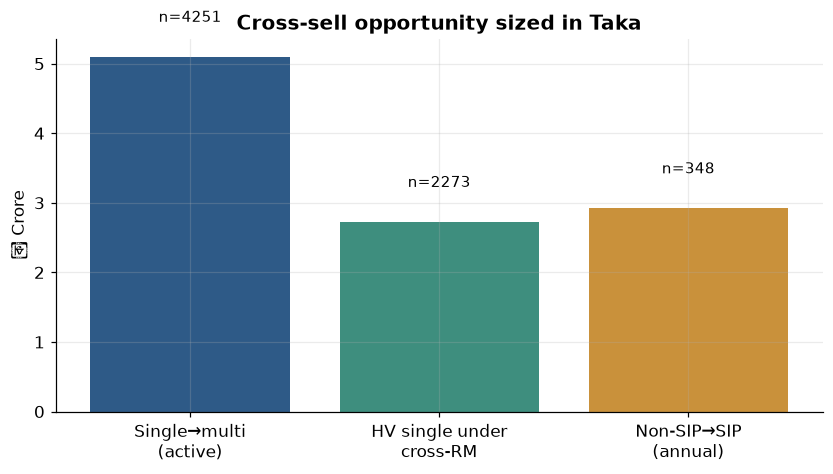

In [25]:
fig,ax=plt.subplots(figsize=(9,4.4))
lab=['Single→multi\n(active)','HV single under\ncross-RM','Non-SIP→SIP\n(annual)']
vals=[p1_val/1e7,p2_val/1e7,p3_val/1e7]
b=ax.bar(lab, vals, color=['#2E5A87','#3E8E7E','#C9913B'])
for r,n in zip(b,[p1_n,p2_n,p3_n]): ax.text(r.get_x()+r.get_width()/2, r.get_height()+.5, f'n={n}', ha='center', fontsize=10)
ax.set_ylabel('৳ Crore'); ax.set_title('Cross-sell opportunity sized in Taka')
C.savefig(fig,SEC,'04_cross_sell'); plt.show()

In [26]:
C.dump_metrics(SEC,metrics)
print('Section 2 metrics persisted.')
print('figures:', sorted(p.name for p in (C.ANALYSIS/SEC/'figures').glob('*.png')))
print('tables :', sorted(p.name for p in (C.ANALYSIS/SEC/'tables').glob('*.csv')))

Section 2 metrics persisted.
figures: ['01_customer_profile.png', '02_cluster_selection.png', '03_segments_scatter.png', '04_cross_sell.png']
tables : ['cluster_fund_map.csv', 'cluster_profiles.csv', 'cluster_selection.csv', 'cross_sell_sizing.csv', 'customer_profile_summary.csv', 'customer_segments.csv']


## 2.4 Section-2 findings (each a Monday decision)
- **The book is concentrated and single-fund.** ~82% of customers hold one fund — the cheapest AUM growth is a second fund to people who already trust Apex, not new acquisition.
- **Target the warm leads first:** high-value single-fund customers whose servicing RM already sells other funds — no new relationship needed, just a conversation.
- **Non-SIP customers are a recurring-revenue reservoir** — convert lump-sum holders to a SIP stream to turn one-off money into a persistency asset.
- Segments are stable across 3 seeds (ARI reported); each segment maps to a primary fund for targeting.

---

# Part 6 · Section 3 — RM productivity + recommendations
*Stitched from `analysis/section3.ipynb` (Agent 2).*

# Section 3 — RM Productivity
**Apex Asset Management case study · Agent 2 (Analysis) · as-of 2026-05-31**

Acquisition metrics are attributed on the **Introducer** role (who onboarded the account) per `definitions.rm` — never blended with the servicing book. We score the 16 official RMs on volume **and** quality (1-year cohort retention), map the volume×value quadrant, measure fund specialisation via **HHI**, and read the team's year-over-year trajectory to separate **systemic** from **individual** problems.

In [27]:
import sys; sys.path.insert(0,'.')
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from analysis import _common as C
defs=C.load_defs(); C.set_style(); SEC='section3'; AS_OF=C.AS_OF
acc=C.load_accounts(); mf=C.load_monthly_flows()
FUNDS=defs['funds']; SHORT=C.FUND_SHORT; COL=C.FUND_COLORS; metrics={}
# Official-RM introduced book (acquisition role)
intro=acc[acc.introducer_in_rmlist].copy()
print('accounts introduced by the 16 official RMs:', len(intro), 'of', len(acc))
print('distinct official introducer RMs:', intro.introducer_rm_name_canon.nunique())

accounts introduced by the 16 official RMs: 5903 of 12229
distinct official introducer RMs: 16


## 3.1 RM scorecard (acquisition role = Introducer)
Per RM: unique customers onboarded, accounts introduced, average installment, **AUM introduced** (current book value of accounts they onboarded), onboarding capital, and headline leakage of their book.

In [28]:
def rm_card(df):
    g=df.groupby('introducer_rm_name_canon')
    sc=g.agg(accounts=('registration_no','size'),
             customers=('mobile_no','nunique'),
             avg_installment=('current_installment_amount','mean'),
             aum_introduced=('investment_value_market','sum'),
             onboarding_capital=('onboarding_amount','sum'),
             sip_share=('is_sip','mean'))
    rate=df[~df.excluded_from_rates]
    rr=rate.groupby('introducer_rm_name_canon').agg(
        churn_strict=('churn_strict','mean'),
        active_now=('is_active','mean'))
    return sc.join(rr)
card=rm_card(intro).sort_values('aum_introduced',ascending=False)
C.save_table(card,SEC,'rm_scorecard')
metrics['rm_scorecard']=card.reset_index().to_dict('records')
disp=card.copy()
disp['avg_installment']=disp.avg_installment.round(0)
disp['aum_introduced_Cr']=(disp.aum_introduced/1e7).round(2)
disp['onboarding_Cr']=(disp.onboarding_capital/1e7).round(2)
for c in ['sip_share','churn_strict','active_now']: disp[c]=(disp[c]*100).round(1)
disp[['accounts','customers','avg_installment','aum_introduced_Cr','onboarding_Cr','sip_share','churn_strict','active_now']]

,accounts,customers,avg_installment,aum_introduced_Cr,onboarding_Cr,sip_share,churn_strict,active_now
introducer_rm_name_canon,,,,,,,,
MST. SHANTA SHEIKH,976,643,17314.0,34.79,16.39,91.4,36.3,59.8
SHARIFA BEGUM,691,511,16619.0,21.40,10.24,92.5,27.2,69.9
SHIBANI DATTA,832,633,12658.0,16.33,7.82,93.1,29.9,66.7
MOHAMMAD JASIM AHMED,727,522,13756.0,14.80,6.88,94.4,24.6,72.4
KAZI JALAL RANA,455,364,17123.0,10.66,4.79,95.2,15.8,81.8
JANNATUL ISLAM,495,403,13430.0,6.44,2.60,95.6,11.1,87.1
MST. SHARMIN BHUIYAN,322,249,10484.0,5.64,3.77,91.0,16.5,80.1
MOST. KAMRUN MIA,370,293,10869.0,5.60,3.25,97.0,11.4,86.8
MOST. SUMAYA SIDDIQUE,325,237,15112.0,4.54,3.37,97.2,24.3,74.5


## 3.2 Per-RM 1-year cohort retention — *acquisition quality*
Volume without retention is churned AUM. For every account we reconstruct its **point-in-time status at onboarding + 12 months** (using dated close/discontinue events, not the current snapshot — see `decisions_log.md`), restricted to accounts old enough to observe that outcome (onboarded ≤ as-of − 12m). Per-RM 1-yr retention = share of their introduced cohort still alive (not strict-churned) at month 12. **High volume + low retention = the flag to coach.**

In [29]:
# observable 12-month cohort: onboarded on/before AS_OF - 12 months
cut = AS_OF - pd.DateOffset(months=12)
obs = intro[intro.first_purchase_date<=cut].copy()
measure = obs.first_purchase_date + pd.DateOffset(months=12)
closed_by = obs.account_closing_date.notna() & (obs.account_closing_date<=measure)
disc_by   = obs.sip_discontinuation_date.notna() & (obs.sip_discontinuation_date<=measure)
obs['retained_12m'] = ~(closed_by|disc_by)
ret=obs.groupby('introducer_rm_name_canon').agg(
    cohort_n=('retained_12m','size'), retention_1yr=('retained_12m','mean'))
card=card.join(ret)
metrics['rm_retention_1yr']=ret.reset_index().to_dict('records')
metrics['overall_retention_1yr']=float(obs.retained_12m.mean())
print(f'Overall 1-yr cohort retention (official-RM book): {obs.retained_12m.mean():.1%}  (n={len(obs)})')
C.save_table(card,SEC,'rm_scorecard_with_retention')
(ret.assign(retention_1yr=(ret.retention_1yr*100).round(1)).sort_values('retention_1yr'))

Overall 1-yr cohort retention (official-RM book): 86.2%  (n=3301)


,cohort_n,retention_1yr
introducer_rm_name_canon,,
MOST. SUMAYA SIDDIQUE,98,74.5
MOHAMMAD JASIM AHMED,422,83.4
MST. RINA AKTER,143,84.6
MOST. KAMRUN MIA,144,84.7
JANNATUL ISLAM,197,85.8
MST. SHARMIN BHUIYAN,165,86.1
SHIBANI DATTA,542,86.3
KAZI JALAL RANA,235,86.4
SHARIFA BEGUM,477,87.6


In [30]:
# Case-specified 1-yr retention (May-2024 cohort -> May-2025), reconstructed point-in-time
co=defs['cohorts']['one_year_retention']
acc_all=acc[~acc.excluded_from_rates]
c0=acc_all[acc_all.onboarding_month==co['cohort_month']].copy()
meas=pd.Timestamp(co['measured_at']+'-28') + pd.offsets.MonthEnd(0)
cb=c0.account_closing_date.notna()&(c0.account_closing_date<=meas)
db=c0.sip_discontinuation_date.notna()&(c0.sip_discontinuation_date<=meas)
c0['retained']=~(cb|db)
metrics['case_2024_05_retention']=dict(cohort_month=co['cohort_month'],measured_at=co['measured_at'],
    denominator=int(len(c0)), numerator=int(c0.retained.sum()), rate=float(c0.retained.mean()))
print(f"Case cohort {co['cohort_month']} -> {co['measured_at']}: "
      f"{int(c0.retained.sum())}/{len(c0)} retained = {c0.retained.mean():.1%}")

Case cohort 2024-05 -> 2025-05: 115/136 retained = 84.6%


## 3.3 Volume × value quadrant + retention overlay
x = customers onboarded (volume), y = AUM introduced per customer (value). Split at medians. Bubble size = cohort size; colour = 1-yr retention. The dangerous quadrant is **high-volume, low-value/low-retention** — RMs spraying low-quality sign-ups.

D:\GitHub\apex\analysis\_common.py:169: UserWarning: Glyph 2547 (\N{BENGALI RUPEE SIGN}) missing from font(s) DejaVu Sans.
  fig.savefig(p)


D:\GitHub\apex\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2547 (\N{BENGALI RUPEE SIGN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


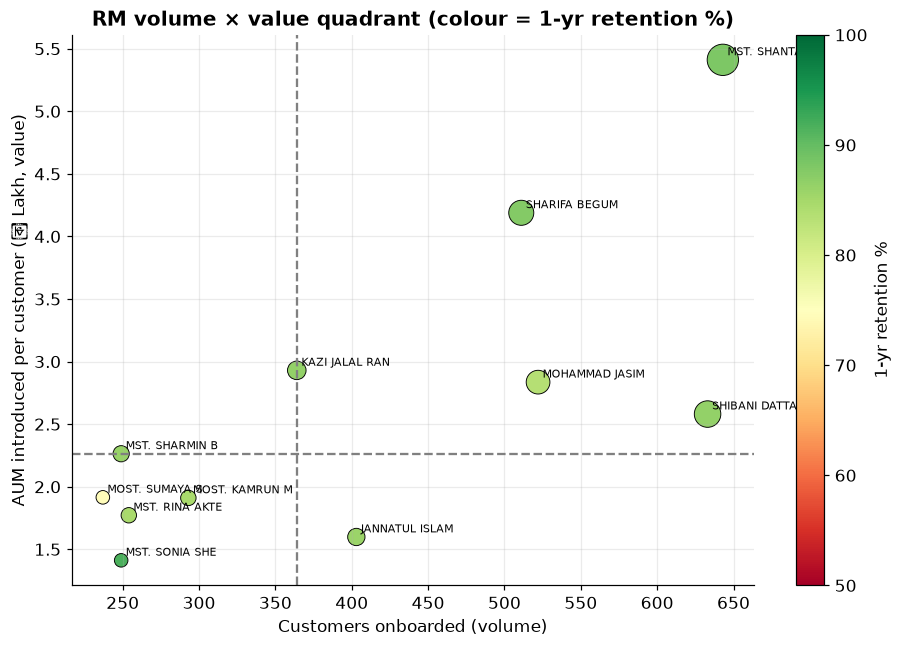

High-volume / low-retention RMs to coach: ['MOHAMMAD JASIM AHMED', 'JANNATUL ISLAM']


In [31]:
q=card.dropna(subset=['retention_1yr']).copy()
q['aum_per_customer']=q.aum_introduced/q.customers
vmed=q.customers.median(); amed=q.aum_per_customer.median()
metrics['quadrant_medians']=dict(volume_median=float(vmed), value_median=float(amed))
fig,ax=plt.subplots(figsize=(10,6.5))
sc=ax.scatter(q.customers, q.aum_per_customer/1e5, s=q.cohort_n/2+30,
    c=q.retention_1yr*100, cmap='RdYlGn', vmin=50, vmax=100, edgecolor='k', linewidth=.6)
ax.axvline(vmed,ls='--',color='grey'); ax.axhline(amed/1e5,ls='--',color='grey')
for n,r in q.iterrows(): ax.annotate(str(n)[:14], (r.customers, r.aum_per_customer/1e5), fontsize=7,
    xytext=(3,3), textcoords='offset points')
ax.set_xlabel('Customers onboarded (volume)'); ax.set_ylabel('AUM introduced per customer (৳ Lakh, value)')
ax.set_title('RM volume × value quadrant (colour = 1-yr retention %)')
plt.colorbar(sc,label='1-yr retention %')
C.savefig(fig,SEC,'01_rm_quadrant'); plt.show()
# explicit high-volume/low-quality flag
flag=q[(q.customers>=vmed)&(q.retention_1yr<q.retention_1yr.median())]
metrics['high_vol_low_quality_rms']=flag.index.tolist()
print('High-volume / low-retention RMs to coach:', flag.index.tolist())

## 3.4 Fund specialisation via HHI
For each RM, HHI of their introduced accounts across the 4 funds (Σ shareᵢ², ×10,000). ~10,000 = one-fund specialist; ~2,500 = perfectly diversified. Specialists are efficient to deploy on their fund but a single-fund concentration risk; generalists are flexible.

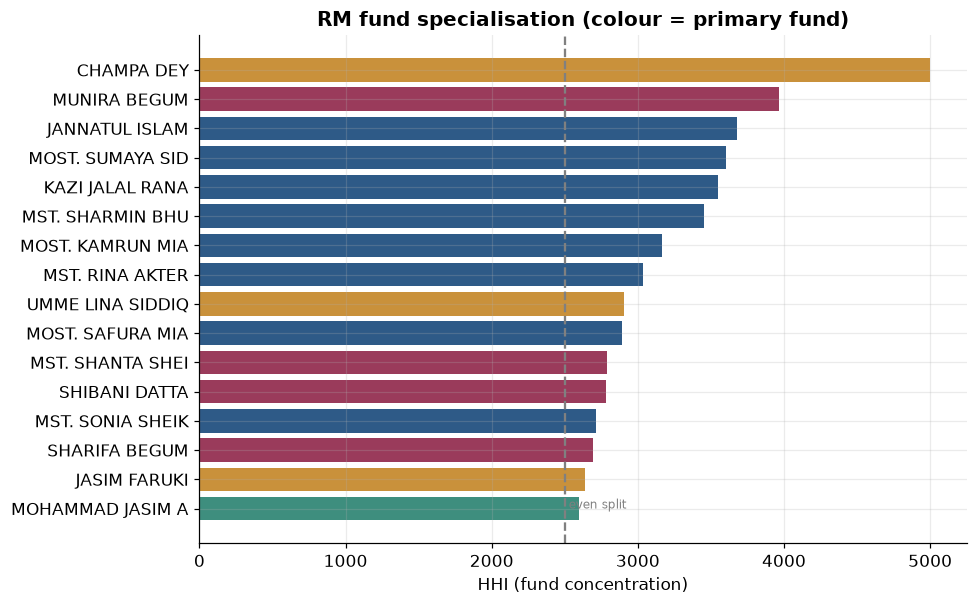

,HHI,primary_fund,accounts
introducer_rm_name_canon,,,
CHAMPA DEY,5000.0,Apex Balanced Opportunity Fund,2
MUNIRA BEGUM,3964.0,Apex Capital Growth Fund,13
JANNATUL ISLAM,3679.0,Apex Fixed Income Fund,495
MOST. SUMAYA SIDDIQUE,3602.0,Apex Fixed Income Fund,325
KAZI JALAL RANA,3548.0,Apex Fixed Income Fund,455
MST. SHARMIN BHUIYAN,3456.0,Apex Fixed Income Fund,322
MOST. KAMRUN MIA,3169.0,Apex Fixed Income Fund,370
MST. RINA AKTER,3037.0,Apex Fixed Income Fund,316
UMME LINA SIDDIQUE,2909.0,Apex Balanced Opportunity Fund,19


In [32]:
def hhi(s):
    p=s.value_counts(normalize=True); return float((p**2).sum()*10000)
hh=intro.groupby('introducer_rm_name_canon').fund.apply(hhi).rename('HHI')
top_fund=intro.groupby('introducer_rm_name_canon').fund.agg(lambda s:s.value_counts().idxmax())
spec=pd.DataFrame({'HHI':hh,'primary_fund':top_fund,'accounts':intro.groupby('introducer_rm_name_canon').size()})
spec=spec.sort_values('HHI',ascending=False)
C.save_table(spec,SEC,'rm_specialization_hhi')
metrics['rm_hhi']=spec.reset_index().to_dict('records')
fig,ax=plt.subplots(figsize=(9,6))
order=spec.sort_values('HHI').index
cols=[COL[spec.loc[n,'primary_fund']] for n in order]
ax.barh([str(n)[:16] for n in order], spec.loc[order,'HHI'], color=cols)
ax.axvline(2500,ls='--',color='grey'); ax.text(2500,0,' even split',fontsize=8,color='grey')
ax.set_xlabel('HHI (fund concentration)'); ax.set_title('RM fund specialisation (colour = primary fund)')
C.savefig(fig,SEC,'02_rm_hhi'); plt.show()
spec.round(0)

## 3.5 Team year-over-year — systemic vs individual
Team trajectory by onboarding year: accounts introduced, 1-yr cohort retention of each vintage, and net flow attributed to that vintage. A falling team-wide retention line is a **systemic** signal (process/incentive); a single RM diverging is **individual** (coaching).

D:\GitHub\apex\analysis\_common.py:169: UserWarning: Glyph 2547 (\N{BENGALI RUPEE SIGN}) missing from font(s) DejaVu Sans.
  fig.savefig(p)


D:\GitHub\apex\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2547 (\N{BENGALI RUPEE SIGN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


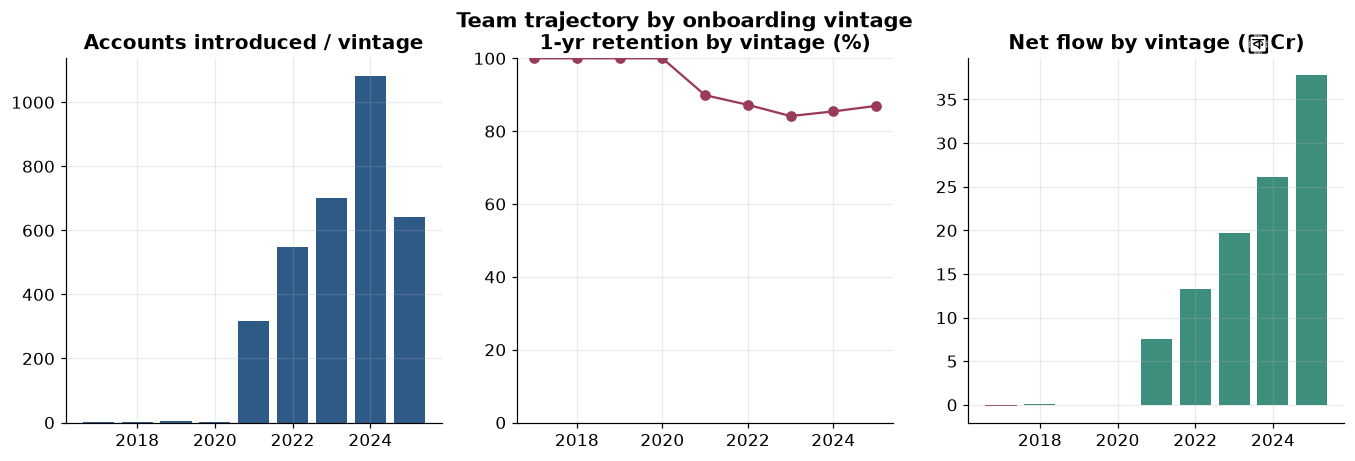

,introduced,retention_1yr,net_flow_Cr
onboarding_year,,,
2017,2,100.0,-0.13
2018,2,100.0,0.11
2019,4,100.0,0.00
2020,3,100.0,-0.02
2021,316,89.9,7.51
2022,548,87.2,13.26
2023,700,84.1,19.71
2024,1083,85.4,26.11
2025,643,86.9,37.82


In [33]:
# vintage retention: reuse point-in-time +12m on the official-RM book by onboarding year
obs_y=intro[intro.first_purchase_date<=cut].copy()
m2=obs_y.first_purchase_date+pd.DateOffset(months=12)
obs_y['retained_12m']=~((obs_y.account_closing_date.notna()&(obs_y.account_closing_date<=m2)) |
                        (obs_y.sip_discontinuation_date.notna()&(obs_y.sip_discontinuation_date<=m2)))
team=obs_y.groupby('onboarding_year').agg(introduced=('registration_no','size'),
    retention_1yr=('retained_12m','mean'))
# net flow by introducing vintage
nf=mf.merge(intro[['registration_no','onboarding_year']],left_on='account_number',right_on='registration_no')
nf_y=nf.groupby('onboarding_year').net_flow.sum()
team['net_flow']=nf_y
C.save_table(team,SEC,'team_yoy')
metrics['team_yoy']=team.reset_index().to_dict('records')
fig,ax=plt.subplots(1,3,figsize=(15,4.3))
yy=team.index.astype(int)
ax[0].bar(yy,team.introduced,color='#2E5A87'); ax[0].set_title('Accounts introduced / vintage')
ax[1].plot(yy,team.retention_1yr*100,'o-',color='#9A3B5B'); ax[1].set_title('1-yr retention by vintage (%)'); ax[1].set_ylim(0,100)
ax[2].bar(yy,team.net_flow/1e7,color=['#3E8E7E' if v>=0 else '#9A3B5B' for v in team.net_flow]); ax[2].set_title('Net flow by vintage (৳Cr)')
fig.suptitle('Team trajectory by onboarding vintage', fontsize=14, fontweight='bold')
C.savefig(fig,SEC,'03_team_yoy'); plt.show()
team.assign(retention_1yr=(team.retention_1yr*100).round(1), net_flow_Cr=(team.net_flow/1e7).round(2)).drop(columns='net_flow')

In [34]:
C.dump_metrics(SEC,metrics)
print('Section 3 metrics persisted.')
print('figures:', sorted(p.name for p in (C.ANALYSIS/SEC/'figures').glob('*.png')))
print('tables :', sorted(p.name for p in (C.ANALYSIS/SEC/'tables').glob('*.csv')))

Section 3 metrics persisted.
figures: ['01_rm_quadrant.png', '02_rm_hhi.png', '03_team_yoy.png']
tables : ['rm_scorecard.csv', 'rm_scorecard_with_retention.csv', 'rm_specialization_hhi.csv', 'team_yoy.csv']


## 3.6 Section-3 findings (each a Monday decision)
- **Rank RMs on retention-adjusted volume, not raw sign-ups.** The volume×value quadrant flags high-volume/low-retention RMs whose AUM leaks back out within a year — coach or re-incentivise them.
- **Specialists vs generalists are different tools:** high-HHI RMs are efficient to deploy on their fund; pair them with the fund that needs growth (Section 1) rather than re-training them.
- **Read the vintage retention line for systemic drift:** if team-wide 1-yr retention is falling across vintages, the fix is process/incentive (systemic), not individual coaching.
- Acquisition (Introducer) and book (Service) are kept separate so we don't credit a servicing RM for another's onboarding.

---

# Part 7 · Cross-cutting synthesis (Fund × Segment × RM)
*Stitched from `analysis/synthesis.ipynb` (Agent 2). Consumes the section metric tables regenerated above (in the deliverable sandbox) — no raw business rule is recomputed.*

# Synthesis — Fund × Segment × RM
**Apex Asset Management case study · Agent 2 (Analysis) · as-of 2026-05-31**

This notebook cross-cuts the three sections into one picture of where AUM is made and lost, then converts every finding into a **specific, owner-assigned recommendation tied to a number**. It consumes the metric tables emitted by `section1/2/3` (no recomputation of raw business rules).

> **Caveat carried forward:** "performance" throughout = flow / retention / engagement, **not** investment return — there is no NAV series in the data.

In [35]:
import sys; sys.path.insert(0,'.')
import json, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from analysis import _common as C
defs=C.load_defs(); C.set_style(); SEC='synthesis'
FUNDS=defs['funds']; SHORT=C.FUND_SHORT; COL=C.FUND_COLORS
A=C.ANALYSIS
m1=json.load(open(A/'section1/_metrics.json'))
m2=json.load(open(A/'section2/_metrics.json'))
m3=json.load(open(A/'section3/_metrics.json'))
acc=C.load_accounts()
seg=pd.read_csv(A/'section2/tables/customer_segments.csv')
seg['mobile_no']=seg['mobile_no'].astype(str); acc['mobile_no']=acc['mobile_no'].astype(str)
print('loaded section metrics + segment table', seg.shape)

loaded section metrics + segment table (8535, 7)


## A. Fund × Segment — who holds what, and where the cross-sell sits
Map customer segments (Section 2) onto their dominant fund. This tells the fund manager which customer type defends each fund and which segment to target for growth.

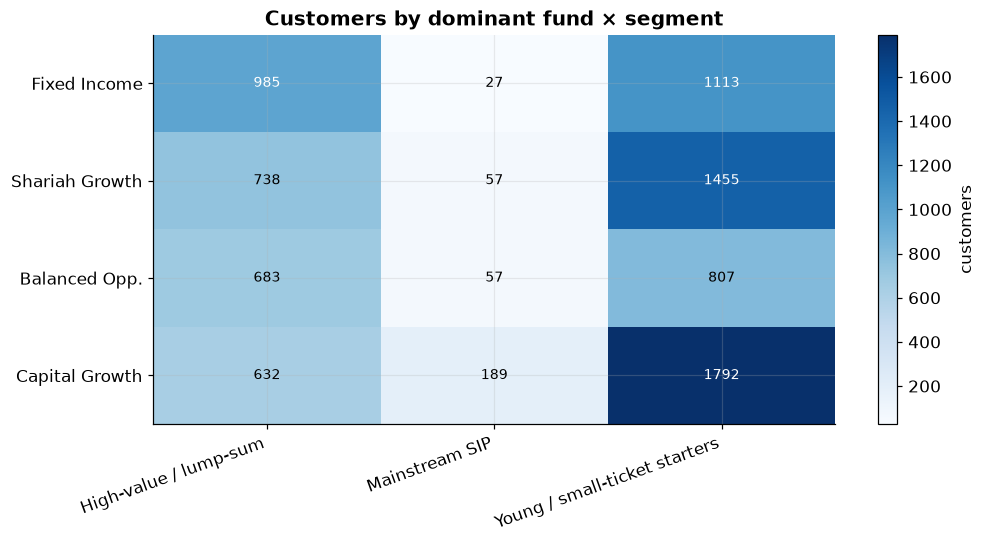

segment,High-value / lump-sum,Mainstream SIP,Young / small-ticket starters
dominant_fund,,,
Apex Fixed Income Fund,985,27,1113
Apex Shariah Growth Fund,738,57,1455
Apex Balanced Opportunity Fund,683,57,807
Apex Capital Growth Fund,632,189,1792


In [36]:
fs=pd.crosstab(seg.dominant_fund, seg.segment)
fs=fs.reindex(FUNDS)
C.save_table(fs,SEC,'fund_x_segment_counts')
fig,ax=plt.subplots(figsize=(10,4.6))
im=ax.imshow(fs.values, cmap='Blues', aspect='auto')
ax.set_xticks(range(len(fs.columns))); ax.set_xticklabels(fs.columns, rotation=20, ha='right')
ax.set_yticks(range(len(fs.index))); ax.set_yticklabels([SHORT[f] for f in fs.index])
for i in range(fs.shape[0]):
    for j in range(fs.shape[1]):
        ax.text(j,i,int(fs.values[i,j]),ha='center',va='center',
                color='white' if fs.values[i,j]>fs.values.max()/2 else 'black', fontsize=9)
ax.set_title('Customers by dominant fund × segment'); plt.colorbar(im,label='customers')
C.savefig(fig,SEC,'01_fund_x_segment'); plt.show()
fs

## B. Fund × RM — align acquisition firepower to the funds that need it
Which RMs introduce each fund's book, overlaid with the fund's leakage (Section 1) and the RM's retention (Section 3). The play: point **high-retention** RMs at the **highest-leakage** funds.

In [37]:
intro=acc[acc.introducer_in_rmlist]
fr=pd.crosstab(intro.introducer_rm_name_canon, intro.fund).reindex(columns=FUNDS).fillna(0).astype(int)
C.save_table(fr,SEC,'fund_x_rm_counts')
# fund leakage (strict churn) from section1 scorecard
sc1=pd.DataFrame(m1['fund_scorecard']).set_index('fund')
rank=pd.DataFrame(m1['fund_ranking']).set_index('fund')
ret3=pd.DataFrame(m3['rm_retention_1yr']).set_index('introducer_rm_name_canon')
print('Fund leakage (strict churn %) and composite rank:')
print((sc1[['churn_strict']].assign(churn_pct=lambda d:(d.churn_strict*100).round(1))
       .join(rank[['composite_score','rank']]))[['churn_pct','composite_score','rank']])
# top introducing RM per fund
top_rm_fund={f: fr[f].idxmax() for f in FUNDS}
print('\nTop introducing RM per fund:')
for f in FUNDS: print(f'  {SHORT[f]:16}: {top_rm_fund[f]} ({fr.loc[top_rm_fund[f],f]} accts)')

Fund leakage (strict churn %) and composite rank:
                                churn_pct  composite_score  rank
fund                                                            
Apex Fixed Income Fund               16.0             98.8     1
Apex Shariah Growth Fund             37.5             59.3     2
Apex Balanced Opportunity Fund       33.7             18.3     4
Apex Capital Growth Fund             47.2             56.5     3

Top introducing RM per fund:
  Fixed Income    : MST. SHANTA SHEIKH (276 accts)
  Shariah Growth  : SHIBANI DATTA (253 accts)
  Balanced Opp.   : MOHAMMAD JASIM AHMED (136 accts)
  Capital Growth  : MST. SHANTA SHEIKH (339 accts)


## C. Segment × RM — who acquires high-value customers
Cross-cut the acquired segment mix per RM. RMs who disproportionately bring in the high-value segment are the template; those bringing only small-ticket starters need a value-mix nudge.

In [38]:
acc_seg=acc.merge(seg[['mobile_no','segment']].drop_duplicates('mobile_no'), on='mobile_no', how='left')
intro_seg=acc_seg[acc_seg.introducer_in_rmlist]
sr=pd.crosstab(intro_seg.introducer_rm_name_canon, intro_seg.segment, normalize='index')*100
C.save_table(sr,SEC,'segment_x_rm_pct')
hv_col=[c for c in sr.columns if 'High-value' in c]
if hv_col:
    hv=sr[hv_col[0]].sort_values(ascending=False)
    print('Share of each RM\'s book that is the High-value segment (%):')
    print(hv.round(1).to_string())
sr.round(1)

Share of each RM's book that is the High-value segment (%):
introducer_rm_name_canon
MST. SHANTA SHEIKH       54.2
SHARIFA BEGUM            44.0
MOST. SUMAYA SIDDIQUE    39.4
MOHAMMAD JASIM AHMED     38.4
SHIBANI DATTA            35.5
MST. RINA AKTER          33.5
KAZI JALAL RANA          29.2
JANNATUL ISLAM           28.3
MST. SHARMIN BHUIYAN     28.1
UMME LINA SIDDIQUE       26.3
MOST. KAMRUN MIA         23.8
MST. SONIA SHEIKH        21.6
MUNIRA BEGUM             15.4
MOST. SAFURA MIA         13.3
JASIM FARUKI             10.2
CHAMPA DEY                0.0


segment,High-value / lump-sum,Mainstream SIP,Young / small-ticket starters
introducer_rm_name_canon,,,
CHAMPA DEY,0.0,0.0,100.0
JANNATUL ISLAM,28.3,2.8,68.9
JASIM FARUKI,10.2,0.0,89.8
KAZI JALAL RANA,29.2,7.1,63.7
MOHAMMAD JASIM AHMED,38.4,4.8,56.8
MOST. KAMRUN MIA,23.8,5.1,71.1
MOST. SAFURA MIA,13.3,6.7,80.0
MOST. SUMAYA SIDDIQUE,39.4,3.1,57.5
MST. RINA AKTER,33.5,8.5,57.9


## D. Consolidated recommendation register
Every finding → a single accountable **owner**, a concrete **action**, and the **number** it is tied to. This is the Monday-morning to-do list.

In [39]:
# pull the numbers we cite so the register is reproducible
worst_fund=rank.sort_values('composite_score').index[0]
best_fund=rank.sort_values('composite_score').index[-1]
leakiest=sc1.churn_strict.idxmax()
xs=pd.DataFrame(m2['cross_sell'])
p1=xs.iloc[0]; p3=xs.iloc[2]
flag_rms=m3['high_vol_low_quality_rms']
surr=m1['surrender_timing']
pers=m1['sip_persistency_overall']
recs=[
 dict(area='Fund', owner='Head of Funds / PM — '+SHORT[worst_fund],
   finding=f'{SHORT[worst_fund]} ranks last on durable-growth composite ({rank.loc[worst_fund,"composite_score"]:.0f}/100)',
   action='Diagnose leakage + redesign retention proposition before chasing new flows', number=f'composite {rank.loc[worst_fund,"composite_score"]:.0f}'),
 dict(area='Fund', owner='Head of Funds / PM — '+SHORT[leakiest],
   finding=f'Highest strict-churn fund = {SHORT[leakiest]} ({sc1.loc[leakiest,"churn_strict"]*100:.1f}%)',
   action='Targeted win-back on closed/discontinued accounts in this fund', number=f'{sc1.loc[leakiest,"churn_strict"]*100:.1f}% churn'),
 dict(area='SIP', owner='Head of Retention / Ops',
   finding=f'Overall SIP persistency {pers*100:.1f}% of expected installments paid; decay accelerates after the early months',
   action='Trigger a save-the-SIP call at the first missed installment (auto-flag from monthly_flows)', number=f'{pers*100:.1f}% persistency'),
 dict(area='Fund', owner='Marketing + PM',
   finding=f'Surrenders run {surr["surrender_share_month_after"]*100:.0f}% in the month AFTER dividends vs {surr["uniform_baseline"]*100:.0f}% uniform',
   action='Pre-empt with a reinvest-your-dividend offer issued WITH each distribution', number=f'{surr["surrender_share_month_after"]*100:.0f}% post-dividend surrenders'),
 dict(area='Cross-sell', owner='Head of Sales',
   finding=f'{int(p1.target_customers)} active single-fund customers; multi-fund penetration low',
   action='Second-fund campaign to single-fund holders via their existing servicing RM', number=C.taka(p1.taka)),
 dict(area='Cross-sell', owner='Head of Sales',
   finding=f'{int(p3.target_customers)} lump-sum-only (Non-SIP) customers carry no recurring stream',
   action='Non-SIP → SIP migration offer to convert one-off money into a persistency asset', number=C.taka(p3.taka)+'/yr'),
 dict(area='RM', owner='Sales Manager (1:1 coaching)',
   finding=f'High-volume / low-retention RMs: {", ".join(flag_rms) if flag_rms else "none flagged"}',
   action='Coach on acquisition quality; tie a slice of incentive to 1-yr retention, not just sign-ups', number=f'{len(flag_rms)} RMs flagged'),
 dict(area='RM', owner='Head of Sales (allocation)',
   finding='Specialist (high-HHI) RMs are concentrated in single funds',
   action=f'Deploy high-retention specialists onto {SHORT[leakiest]} (highest-leakage fund)', number='HHI map in section3'),
]
reg=pd.DataFrame(recs)[['area','owner','finding','action','number']]
C.save_table(reg,SEC,'recommendation_register',index=False)
json.dump({'worst_fund':worst_fund,'best_fund':best_fund,'leakiest_fund':leakiest,
           'flag_rms':flag_rms}, open(A/SEC/'_metrics.json','w'), indent=2)
pd.set_option('display.max_colwidth',60)
reg

,area,owner,finding,action,number
0,Fund,Head of Funds / PM — Balanced Opp.,Balanced Opp. ranks last on durable-growth composite (18...,Diagnose leakage + redesign retention proposition before...,composite 18
1,Fund,Head of Funds / PM — Capital Growth,Highest strict-churn fund = Capital Growth (47.2%),Targeted win-back on closed/discontinued accounts in thi...,47.2% churn
2,SIP,Head of Retention / Ops,Overall SIP persistency 87.9% of expected installments p...,Trigger a save-the-SIP call at the first missed installm...,87.9% persistency
3,Fund,Marketing + PM,Surrenders run 20% in the month AFTER dividends vs 17% u...,Pre-empt with a reinvest-your-dividend offer issued WITH...,20% post-dividend surrenders
4,Cross-sell,Head of Sales,4251 active single-fund customers; multi-fund penetratio...,Second-fund campaign to single-fund holders via their ex...,৳5.1 Cr
5,Cross-sell,Head of Sales,348 lump-sum-only (Non-SIP) customers carry no recurring...,Non-SIP → SIP migration offer to convert one-off money i...,৳2.9 Cr/yr
6,RM,Sales Manager (1:1 coaching),"High-volume / low-retention RMs: MOHAMMAD JASIM AHMED, J...",Coach on acquisition quality; tie a slice of incentive t...,2 RMs flagged
7,RM,Head of Sales (allocation),Specialist (high-HHI) RMs are concentrated in single funds,Deploy high-retention specialists onto Capital Growth (h...,HHI map in section3


D:\GitHub\apex\analysis\_common.py:169: UserWarning: Glyph 2547 (\N{BENGALI RUPEE SIGN}) missing from font(s) DejaVu Sans.
  fig.savefig(p)
D:\GitHub\apex\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2547 (\N{BENGALI RUPEE SIGN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


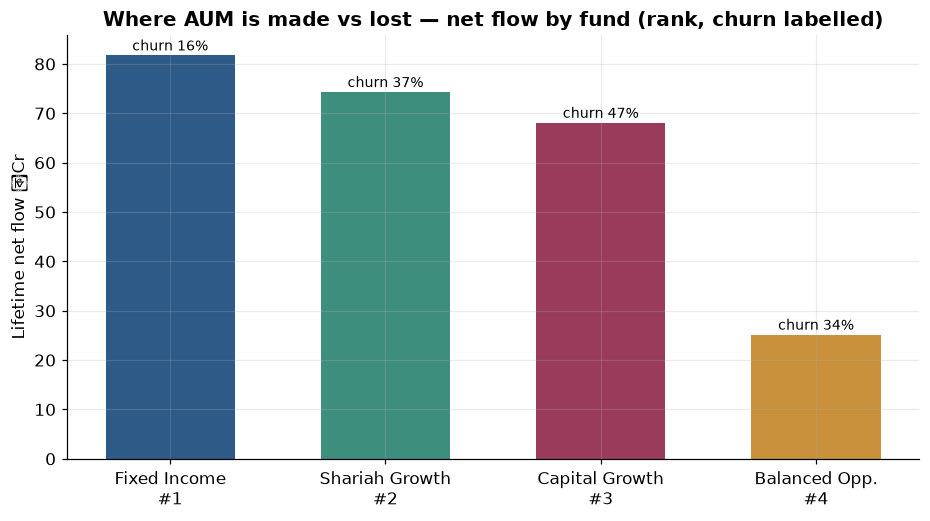

figures: ['01_fund_x_segment.png', '02_aum_made_vs_lost.png']
tables : ['fund_x_rm_counts.csv', 'fund_x_segment_counts.csv', 'recommendation_register.csv', 'segment_x_rm_pct.csv']


In [40]:
# one consolidated 'where AUM is made vs lost' chart for the deck
fig,ax=plt.subplots(figsize=(10,5))
order=rank.sort_values('composite_score',ascending=False).index
x=np.arange(len(order)); w=0.6
nf=[sc1.loc[f,'net_flow_value']/1e7 for f in order]
ax.bar(x, nf, w, color=[COL[f] for f in order])
for xi,f in zip(x,order):
    ax.text(xi, nf[list(order).index(f)]+1, f"churn {sc1.loc[f,'churn_strict']*100:.0f}%", ha='center', fontsize=9)
ax.set_xticks(x); ax.set_xticklabels([f'{SHORT[f]}\n#{int(rank.loc[f,"rank"])}' for f in order])
ax.set_ylabel('Lifetime net flow ৳Cr'); ax.set_title('Where AUM is made vs lost — net flow by fund (rank, churn labelled)')
C.savefig(fig,SEC,'02_aum_made_vs_lost'); plt.show()
print('figures:', sorted(p.name for p in (A/SEC/'figures').glob('*.png')))
print('tables :', sorted(p.name for p in (A/SEC/'tables').glob('*.csv')))

## Synthesis headline
**Apex's growth problem is a retention problem, not an acquisition problem.** Net flow is strongly positive and growing, but it is concentrated in one fund (Fixed Income) while the others leak; the base is overwhelmingly single-fund; and a couple of high-volume RMs acquire faster than they retain. The three highest-leverage moves — all owner-assigned above — are: (1) defend the leakiest fund and fix SIP persistency at the first missed installment, (2) run a second-fund campaign to existing single-fund customers (cheapest AUM available), and (3) re-tie RM incentives to 1-year retention. See `recommendation_register.csv` for the full owner-assigned list.

---

## 8. Consolidated recommendations + appendix

### 8.1 Recommendation register — every number → a specific, owner-assigned action
The Monday-morning to-do list. Each row ties a finding to a single accountable owner, a concrete action, and the number it rests on (reproduced from the section metrics above).

In [41]:
import pandas as pd
reg = pd.read_csv(C.ANALYSIS / 'synthesis' / 'tables' / 'recommendation_register.csv')
pd.set_option('display.max_colwidth', 80)
reg

,area,owner,finding,action,number
0,Fund,Head of Funds / PM — Balanced Opp.,Balanced Opp. ranks last on durable-growth composite (18/100),Diagnose leakage + redesign retention proposition before chasing new flows,composite 18
1,Fund,Head of Funds / PM — Capital Growth,Highest strict-churn fund = Capital Growth (47.2%),Targeted win-back on closed/discontinued accounts in this fund,47.2% churn
2,SIP,Head of Retention / Ops,Overall SIP persistency 87.9% of expected installments paid; decay accelerat...,Trigger a save-the-SIP call at the first missed installment (auto-flag from ...,87.9% persistency
3,Fund,Marketing + PM,Surrenders run 20% in the month AFTER dividends vs 17% uniform,Pre-empt with a reinvest-your-dividend offer issued WITH each distribution,20% post-dividend surrenders
4,Cross-sell,Head of Sales,4251 active single-fund customers; multi-fund penetration low,Second-fund campaign to single-fund holders via their existing servicing RM,৳5.1 Cr
5,Cross-sell,Head of Sales,348 lump-sum-only (Non-SIP) customers carry no recurring stream,Non-SIP → SIP migration offer to convert one-off money into a persistency asset,৳2.9 Cr/yr
6,RM,Sales Manager (1:1 coaching),"High-volume / low-retention RMs: MOHAMMAD JASIM AHMED, JANNATUL ISLAM","Coach on acquisition quality; tie a slice of incentive to 1-yr retention, no...",2 RMs flagged
7,RM,Head of Sales (allocation),Specialist (high-HHI) RMs are concentrated in single funds,Deploy high-retention specialists onto Capital Growth (highest-leakage fund),HHI map in section3


### 8.2 Prioritised roadmap
1. **Now (0–3 mo) — stop the leak.** Auto-flag the first missed SIP installment (`monthly_flows`) and fire a save-call; launch a win-back on closed/discontinued accounts in **Capital Growth** (47.2% strict churn). Owner: Head of Retention / PM.
2. **Now (0–3 mo) — cheapest AUM.** Second-fund campaign to the **4,251** active single-fund customers (~৳5.1 Cr), starting with the **2,273** high-value leads already under a cross-capable RM. Owner: Head of Sales.
3. **Next (3–6 mo) — fix incentives.** Re-tie a slice of RM incentive to **1-year retention**, not raw sign-ups; coach the two high-volume / below-median-retention RMs. Owner: Sales Manager.
4. **Next (3–6 mo) — recurring revenue.** Non-SIP → SIP migration offer to the **348** lump-sum-only customers (~৳2.9 Cr/yr). Owner: Head of Sales.
5. **Ongoing — pre-empt redemptions.** Issue a dividend-reinvestment offer *with* each Jul/Jan distribution (surrenders run ~20.4% in the month after a dividend vs 16.7% baseline). Owner: Marketing + PM.

### 8.3 Assumptions & limitations
- **No NAV / return series** → "performance" = flow / retention / engagement only (restated throughout). `Investment Value (At Market)` used as current book/AUM, never as return.
- **Point-in-time cohort reconstruction** from dated events (not the current snapshot); case 1-yr retention = 84.6% point-in-time vs 93/136 snapshot.
- **Churn = strict (Closed + Discontinued)** headline; Inactive shown only as `churn_broad` sensitivity; Suspended (2) excluded from denominators.
- **Cross-sell Taka = target count × explicit median ticket** (2nd-fund ৳12,000; SIP annual ৳84,000); headline wallet = Play 1 + Play 3 (Play 2 is a subset of Play 1, not double-counted).
- **Clustering** at customer level, k=4 (silhouette 0.42; ARI=1.0 across seeds 42/7/123); k=2 rejected as the trivial SIP-vs-Non-SIP split; monetary features log1p-scaled.
- **RM metrics** on the Introducer (acquisition) role, restricted to the 16 official RMs; 1-yr retention only on cohorts old enough to observe the outcome (onboarded ≤ as-of − 12m).
- **3 orphan ledger accounts** (6 rows) quarantined; documented anomalies (3 closed / 1 disc. without event date) censored, not dropped.

### 8.4 Derived-field dictionary
Full field-by-field definitions for every consumed column are in `clean/derived_field_dictionary.md` (accounts / customers / transactions / monthly_flows / rm_attribution). The locked business rules are in `definitions.yaml`; every judgment call is in `decisions_log.md`; QA reproduction is in `qa/qa_report.md` (GATE 1 & GATE 2 both PASS).

In [42]:
# Provenance footer: confirm the deliverable consumed only clean/ + regenerated its own sandbox
figs = sorted(p.relative_to(REPO).as_posix() for p in (C.ANALYSIS).rglob('figures/*.png'))
tbls = sorted(p.relative_to(REPO).as_posix() for p in (C.ANALYSIS).rglob('tables/*.csv'))
print('regenerated figures:', len(figs), '| regenerated tables:', len(tbls))
print('analysis/ artifacts left untouched (QA-validated).')
print('END OF NOTEBOOK — assembled by deliverables/make_deliverable.py')

regenerated figures: 16 | regenerated tables: 22
analysis/ artifacts left untouched (QA-validated).
END OF NOTEBOOK — assembled by deliverables/make_deliverable.py
